# Leakage-safe velocity prediction from cleaned IMU data

This notebook connects the deterministic IDR sensor pipeline to a fair velocity-model comparison. It displays original and cleaned measurements, audits preprocessing losses, simulates GNSS blackouts, performs journey-grouped cross-validation, and evaluates errors in real speed units.

The key correction is the target formulation. A short IMU window describes changes in motion, but steady travel at 30 km/h can look like steady travel at 90 km/h. The primary models therefore start with the last trustworthy GNSS speed and learn the change in speed since that anchor. Cleaned forward-acceleration integration remains an input feature and a deterministic baseline, rather than a base estimate the model must undo.

## Problems being addressed

- Direct speed models regress toward the dataset mean because absolute speed is not observable from steady-motion IMU alone.
- Randomly splitting overlapping windows would leak near-duplicates into validation. Every split here keeps complete journeys together.
- A few large journeys dominate the usable data, while earlier preprocessing did not attribute every rejected row.
- The old RF used only 24 range statistics and missed vibration shape and frequency.
- Twenty-five neural epochs with patience five can stop too early. The full profile allows 200 epochs, patience 20, and restores the best fold checkpoint.
- One overall MAE hides high-speed and long-outage failures, so results are sliced by journey, speed, and blackout horizon.

In [25]:
from __future__ import annotations
import json, sys, time
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'src' / 'idr_backend').is_dir():
            return candidate
    raise RuntimeError('Open this notebook inside the dead reckoning repository.')

REPO_ROOT = find_repo_root(Path.cwd().resolve())
NOTEBOOK_DIR = REPO_ROOT / 'notebooks'
for local_path in (REPO_ROOT / 'src', NOTEBOOK_DIR):
    if str(local_path) not in sys.path:
        sys.path.insert(0, str(local_path))
RAW_DATA_DIR = REPO_ROOT / 'SIH-2-main' / 'SIH-2-main' / 'IOVNBD-Speed-Prediction' / 'data' / 'raw'
ARTIFACT_DIR = REPO_ROOT / 'artifacts' / 'anchored_velocity_comparison'
assert RAW_DATA_DIR.is_dir(), f'Missing data: {RAW_DATA_DIR}'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
print(REPO_ROOT, RAW_DATA_DIR, ARTIFACT_DIR, sep='\n')

E:\dead reckoning
E:\dead reckoning\SIH-2-main\SIH-2-main\IOVNBD-Speed-Prediction\data\raw
E:\dead reckoning\artifacts\anchored_velocity_comparison


In [26]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from velocity_experiment import (
    CONTEXT_FEATURE_NAMES, RAW_FEATURE_NAMES, VELOCITY_MODEL_FEATURE_NAMES,
    ExperimentConfig, assert_group_isolation, build_blackout_dataset,
    choose_grouped_holdout, config_dict, detailed_error_frame,
    fit_final_absolute_neural, fit_final_forest, fit_final_neural,
    fold_audit_frame, make_grouped_cv_folds, measure_latency_ms,
    neural_parameter_samples, paired_paths, predict_final_absolute_neural,
    predict_final_forest, predict_final_neural, read_aligned_journey,
    preprocessing_physics_audit, regression_metrics, replay_clean_journey, rf_imu_features, rf_parameter_grid,
    transform_context, transform_sequence, tune_absolute_neural_baseline,
    tune_neural_family, tune_random_forest,
)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Python {sys.version.split()[0]} | PyTorch {torch.__version__} | {DEVICE}')
if DEVICE.type == 'cuda': print(torch.cuda.get_device_name(0))

Python 3.12.4 | PyTorch 2.7.1+cu118 | cuda
NVIDIA GeForce GTX 1650 with Max-Q Design


## Configuration

Full runs 20 reproducibly sampled candidates for each neural family, the complete 108-point RF grid, five grouped folds, and early stopping up to 200 epochs. Smoke is only a quick wiring check and must not be reported as a model result. A full search can take several hours on a GTX 1650.

In [29]:
SEARCH_PROFILE = 'full'  # Complete 20 GRU + 20 CNN + 108 RF grouped search.
ALLOW_DIAGNOSTIC_FULL_RUN = True
REBUILD_PREPROCESSING = False
CONFIG = ExperimentConfig(search_profile=SEARCH_PROFILE)
print(json.dumps(config_dict(CONFIG), indent=2))
print('GRU candidates:', len(neural_parameter_samples('gru', CONFIG)))
print('CNN candidates:', len(neural_parameter_samples('cnn', CONFIG)))
print('RF candidates: ', len(rf_parameter_grid(CONFIG)))

{
  "sample_period_ns": 100000000,
  "window_size": 50,
  "calibration_history_s": 30.0,
  "calibration_update_every_samples": 10,
  "minimum_calibration_samples": 5,
  "minimum_calibration_confidence": 0.6,
  "label_alignment_tolerance_ms": 75.0,
  "max_gap_ns": 250000000,
  "max_linear_acceleration_mps2": 30.0,
  "max_angular_velocity_radps": 12.0,
  "blackout_horizons_s": [
    5,
    10,
    20,
    30,
    60,
    90,
    120
  ],
  "anchor_stride_s": 10,
  "test_fraction": 0.15,
  "cv_folds": 5,
  "seed": 42,
  "batch_size": 128,
  "maximum_epochs": 200,
  "early_stopping_patience": 20,
  "weight_decay": 0.0001,
  "huber_beta_mps": 1.0,
  "neural_candidates_per_family": 20,
  "inference_warmup_calls": 30,
  "inference_measurement_calls": 200,
  "search_profile": "full"
}
GRU candidates: 20
CNN candidates: 20
RF candidates:  108


## 1. Original phone and CAN data

S files provide phone accelerometer, gyroscope, and GPS speed. V files provide the CAN-bus target. They are aligned by elapsed time within 75 ms, never by blindly truncating rows. The source GPS header says Kmh, but the recorded values numerically behave as m/s: multiplying them by 3.6 aligns them with the independent CAN km/h traces. The ingestion helper documents and applies this dataset-specific correction. GPS is used only for past-only calibration evidence and the blackout-start anchor; CAN speed is a label only.

Found 40 complete recording pairs.


,journey_id,timestamp,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,gps_speed_file_value,gps_speed_kmh,target_speed_kmh
0,M,2019-09-07 09:13:29.506,-0.9684,-0.0227,9.9665,-0.0368,-0.1089,-0.0045,5.84,21.024,20.10
1,M,2019-09-07 09:13:29.606,-0.3069,-1.3369,9.9218,-0.0056,-0.1285,0.0214,5.84,21.024,20.55
2,M,2019-09-07 09:13:29.706,-0.0226,-2.0653,10.0332,0.0092,-0.1373,-0.0368,5.84,21.024,20.93
3,M,2019-09-07 09:13:29.806,0.0734,-1.5827,10.2690,-0.0184,-0.1226,-0.0183,5.84,21.024,21.05
4,M,2019-09-07 09:13:29.907,0.1095,-0.0062,9.9086,-0.0627,-0.0649,-0.0010,5.84,21.024,21.27
5,M,2019-09-07 09:13:30.006,0.7304,-0.6970,10.2125,-0.0540,-0.0781,0.0512,5.84,21.024,21.50
6,M,2019-09-07 09:13:30.106,0.7136,0.2314,9.9019,-0.0292,-0.0156,0.0156,5.84,21.024,21.61
7,M,2019-09-07 09:13:30.206,-0.1565,-0.5425,9.7293,-0.0417,-0.0319,-0.0316,5.84,21.024,21.74
8,M,2019-09-07 09:13:30.306,0.4673,-0.3767,9.9896,-0.1118,0.0814,-0.0318,5.84,21.024,21.97
9,M,2019-09-07 09:13:30.406,0.0178,0.0381,10.2658,-0.0468,0.0124,0.0235,5.84,21.024,22.08


,interpretation,example_mae_against_can_kmh
0,header literally as km/h,26.342149
1,"recorded value as m/s, converted to km/h",4.915072


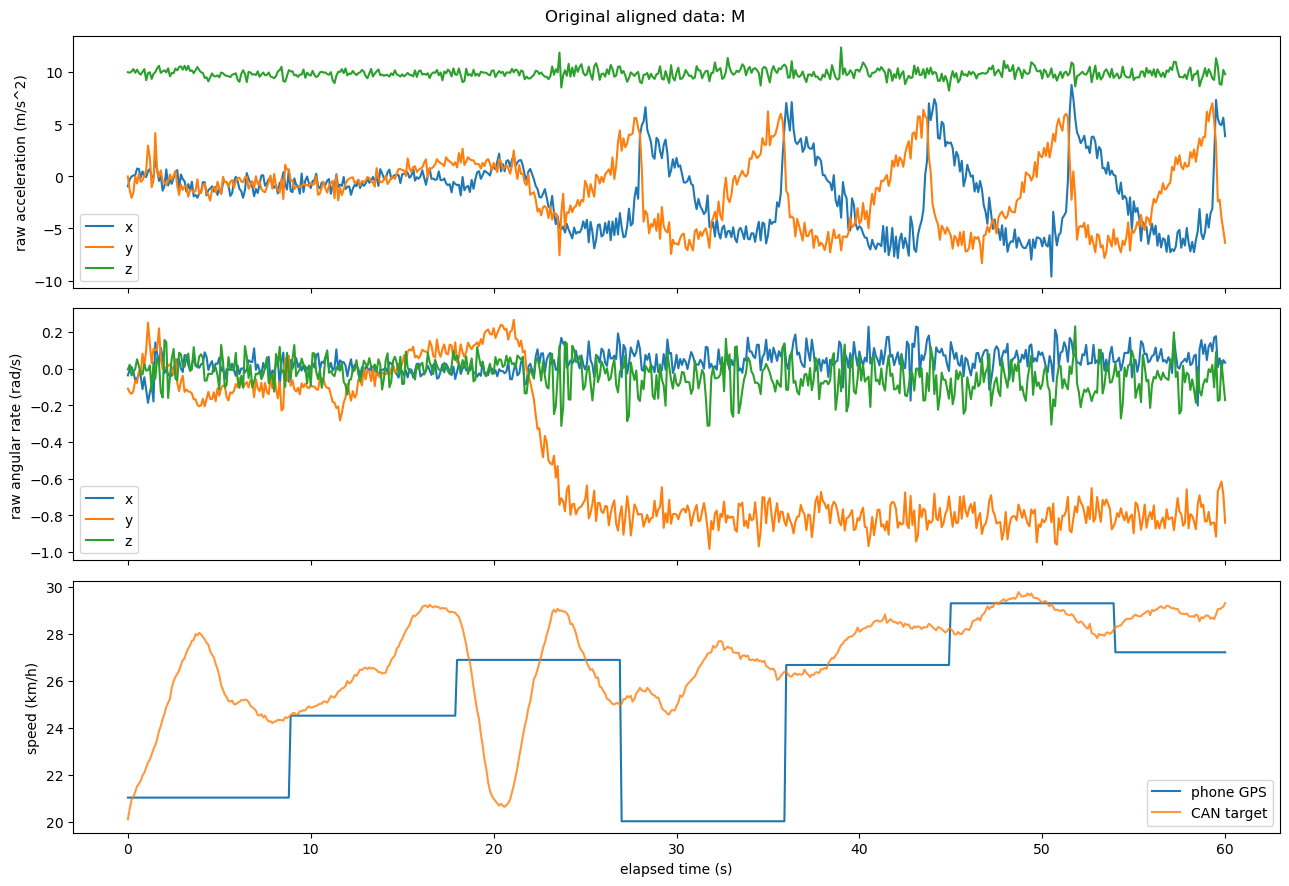

In [30]:
pairs = paired_paths(RAW_DATA_DIR)
example_frame = read_aligned_journey(*pairs[0], CONFIG)
original_columns = ['journey_id', 'timestamp', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'gps_speed_file_value', 'gps_speed_kmh', 'target_speed_kmh']
print(f'Found {len(pairs)} complete recording pairs.')
display(example_frame[original_columns].head(12))
unit_audit = pd.DataFrame({'interpretation':['header literally as km/h','recorded value as m/s, converted to km/h'], 'example_mae_against_can_kmh':[np.mean(np.abs(example_frame.gps_speed_file_value-example_frame.target_speed_kmh)), np.mean(np.abs(example_frame.gps_speed_kmh-example_frame.target_speed_kmh))]})
display(unit_audit)
raw_plot = example_frame.iloc[:min(600, len(example_frame))].copy()
raw_plot['elapsed_s'] = (raw_plot.timestamp_ns - raw_plot.timestamp_ns.iloc[0]) * 1e-9
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
axes[0].plot(raw_plot.elapsed_s, raw_plot[['acc_x', 'acc_y', 'acc_z']]); axes[0].set_ylabel('raw acceleration (m/s^2)'); axes[0].legend(['x', 'y', 'z'])
axes[1].plot(raw_plot.elapsed_s, raw_plot[['gyro_x', 'gyro_y', 'gyro_z']]); axes[1].set_ylabel('raw angular rate (rad/s)'); axes[1].legend(['x', 'y', 'z'])
axes[2].plot(raw_plot.elapsed_s, raw_plot.gps_speed_kmh, label='phone GPS'); axes[2].plot(raw_plot.elapsed_s, raw_plot.target_speed_kmh, label='CAN target', alpha=.8)
axes[2].set_ylabel('speed (km/h)'); axes[2].set_xlabel('elapsed time (s)'); axes[2].legend()
fig.suptitle(f'Original aligned data: {example_frame.journey_id.iloc[0]}'); fig.tight_layout(); plt.show()

## 2. Deterministic preprocessing and retention audit

Each row passes through the package implementations of unit normalization, synchronization, orientation estimation, phone-to-vehicle calibration, gravity removal, quality checks, and fixed-rate resampling. This dataset is already SI and its paired channels share timestamps, so normalization and synchronization validate rather than visibly filter it. Rotation into Forward-Left-Up and gravity removal create the meaningful representation change.

The cache contains deterministic outputs only. Rebuild it after changing sensor-pipeline code or preprocessing settings.

In [31]:
PREPROCESSING_CACHE = ARTIFACT_DIR / 'processed_journeys.joblib'
cache_key = {'preprocessing_revision': 4, 'sample_period_ns': CONFIG.sample_period_ns, 'minimum_calibration_confidence': CONFIG.minimum_calibration_confidence, 'calibration_history_s': CONFIG.calibration_history_s}
cached = joblib.load(PREPROCESSING_CACHE) if PREPROCESSING_CACHE.exists() and not REBUILD_PREPROCESSING else {}
cache_is_usable = cached.get('cache_key') == cache_key
if cache_is_usable:
    processed_journeys, skipped_journeys = cached['journeys'], cached['skipped']
    print(f'Loaded {len(processed_journeys)} cached journeys.')
else:
    processed_journeys, skipped_journeys = [], []
    for pair in pairs:
        try:
            aligned = read_aligned_journey(*pair, CONFIG)
            journey = replay_clean_journey(aligned, CONFIG)
            processed_journeys.append(journey)
            print(f'{pair[0]}: {len(journey.clean_imu):,} cleaned rows')
        except (KeyError, ValueError) as error:
            skipped_journeys.append({'journey_id': pair[0], 'reason': str(error)})
            print(f'{pair[0]}: skipped - {error}')
    joblib.dump({'cache_key': cache_key, 'journeys': processed_journeys, 'skipped': skipped_journeys}, PREPROCESSING_CACHE)
if len(processed_journeys) < CONFIG.cv_folds + 1:
    raise RuntimeError('Too few usable journeys for grouped CV and a frozen test set.')

Loaded 25 cached journeys.


In [32]:
audit_frame = pd.DataFrame([journey.audit for journey in processed_journeys]).fillna(0)
skipped_frame = pd.DataFrame(skipped_journeys)
display(audit_frame.sort_values('resampled_rows', ascending=False))
if not skipped_frame.empty: display(skipped_frame)
stages = ['source_rows', 'normalized_and_synchronized', 'rows_before_calibration', 'rows_using_held_calibration', 'rows_below_calibration_confidence', 'quality_rejected_rows', 'quality_accepted_rows', 'resampled_rows']
source_total = max(1, int(audit_frame.source_rows.sum()))
retention = pd.DataFrame({'stage_or_reason': stages, 'rows': [int(audit_frame.get(stage, pd.Series(dtype=float)).sum()) for stage in stages]})
retention['percent_of_aligned_input'] = retention.rows / source_total * 100
display(retention)

,journey_id,source_rows,normalized_and_synchronized,rows_before_calibration,calibration_updates_without_evidence,calibration_evidence_updates,rows_below_calibration_confidence,quality_accepted_rows,resampled_rows,rows_using_held_calibration,quality_rejected_rows,quality_linear_acceleration_limit_exceeded,quality_angular_velocity_limit_exceeded,quality_sensor_gap,contiguous_segments,final_calibration_confidence,calibration_phase
0,M,105950,105950,119,1105,9490,50.0,105774,105775,34410,7.0,3.0,3.0,2.0,4,0.605130,tracking
2,S2,93865,93865,279,1553,7833,0.0,93583,93583,36316,3.0,2.0,1.0,1.0,4,0.600000,degraded
6,S4,91468,91468,129,1697,7449,0.0,91336,91334,29249,3.0,1.0,1.0,2.0,4,0.600000,tracking
24,Y1,68918,68918,89,2229,4662,40.0,68782,68778,35639,7.0,2.0,4.0,3.0,6,0.600000,degraded
8,Vfa02,67523,67523,199,3058,3694,0.0,67324,67324,37424,0.0,0.0,0.0,0.0,1,0.600000,tracking
1,S1,51746,51746,119,539,4635,0.0,51627,51626,16320,0.0,0.0,0.0,0.0,1,0.705826,tracking
5,S3c,37183,37183,129,390,3328,0.0,37054,37053,11050,0.0,0.0,0.0,0.0,1,0.782438,tracking
13,Vta1a,25676,25676,389,1097,1470,0.0,25287,25286,17557,0.0,0.0,0.0,0.0,1,0.600000,tracking
3,S3a,24621,24621,139,232,2230,0.0,24482,24482,6900,0.0,0.0,0.0,0.0,1,0.912216,tracking
20,Vta29,23701,23701,209,792,1578,0.0,23492,23489,12712,0.0,0.0,0.0,0.0,1,0.600000,tracking


,journey_id,reason
0,Vta11,Journey produced too little contiguous cleaned...
1,Vta12,Journey produced too little contiguous cleaned...
2,Vta13,Journey produced too little contiguous cleaned...
3,Vta15,Journey produced too little contiguous cleaned...
4,Vta19,Journey produced too little contiguous cleaned...
5,Vta1b,Journey produced too little contiguous cleaned...
6,Vta20,Journey produced too little contiguous cleaned...
7,Vta23,Journey produced too little contiguous cleaned...
8,Vta24,Journey produced too little contiguous cleaned...
9,Vta25,Journey produced too little contiguous cleaned...


,stage_or_reason,rows,percent_of_aligned_input
0,source_rows,675056,100.000000
1,normalized_and_synchronized,675056,100.000000
2,rows_before_calibration,3675,0.544399
3,rows_using_held_calibration,276498,40.959269
4,rows_below_calibration_confidence,170,0.025183
5,quality_rejected_rows,26,0.003852
6,quality_accepted_rows,671185,99.426566
7,resampled_rows,671169,99.424196


## 3. Original versus preprocessed data

The table uses matching resampled timestamps. Raw is the arbitrary phone frame. Vehicle specific force is after mounting calibration but before gravity removal. Clean is Forward-Left-Up linear acceleration after gravity compensation plus the rotated gyroscope. Plot downsampling affects display only, never training.

,timestamp_ns,raw_acceleration_x_mps2,raw_acceleration_y_mps2,raw_acceleration_z_mps2,raw_angular_velocity_x_radps,raw_angular_velocity_y_radps,raw_angular_velocity_z_radps,vehicle_before_gravity_ax,vehicle_before_gravity_ay,vehicle_before_gravity_az,...,vehicle_before_gravity_gz,clean_linear_acceleration_x_mps2,clean_linear_acceleration_y_mps2,clean_linear_acceleration_z_mps2,clean_angular_velocity_x_radps,clean_angular_velocity_y_radps,clean_angular_velocity_z_radps,gps_speed_kmh,can_target_kmh,calibration_confidence
0,1567847626407000000,-0.284600,1.636300,10.180000,-0.054700,0.158700,0.017100,-1.871161,-1.377983,10.049417,...,0.010286,-1.388534,-0.560319,0.288840,-0.073187,-0.151684,0.010286,24.515999,29.150000,0.642194
1,1567847626507000000,0.455251,1.390277,9.675372,-0.047671,0.091237,-0.005122,-2.179987,-0.684130,9.514860,...,-0.007924,-1.703985,0.154990,-0.244221,-0.029158,-0.098539,-0.007924,24.515999,29.139297,0.642194
2,1567847626607000000,-0.371361,1.248506,9.932394,-0.014713,0.065627,-0.007320,-1.516586,-1.161339,9.833635,...,-0.010590,-1.043899,-0.274564,0.078612,-0.034571,-0.057181,-0.010590,24.515999,29.070400,0.642194
3,1567847626707000000,-0.375771,1.158088,9.197742,0.023163,0.108140,-0.008885,-1.383070,-1.099119,9.108232,...,-0.017364,-0.918907,-0.113270,-0.637689,-0.090993,-0.061061,-0.017364,24.515999,29.109701,0.642194
4,1567847626807000000,-0.219222,0.977347,10.031737,-0.019639,0.131415,0.032025,-1.445087,-0.861240,9.940271,...,0.024642,-1.031025,0.191058,0.199046,-0.080500,-0.107674,0.024642,24.515999,29.080099,0.642194
5,1567847626907000000,-0.688377,1.820848,9.860810,0.025821,0.083347,0.014417,-1.683092,-1.792021,9.745809,...,0.007275,-1.245083,-0.632691,0.017786,-0.077752,-0.041507,0.007275,24.515999,29.088909,0.642194
6,1567847627007000000,-0.856100,1.555600,10.221800,0.007900,0.078000,-0.013900,-1.412096,-1.720159,10.133362,...,-0.019413,-0.977691,-0.482186,0.414870,-0.058678,-0.050196,-0.019413,24.515999,28.980000,0.642194
7,1567847627107000000,-0.765620,1.421754,10.020375,-0.021538,0.131650,-0.028974,-1.364774,-1.561030,9.935596,...,-0.035992,-0.991183,-0.239860,0.225541,-0.073716,-0.109112,-0.035992,24.515999,28.920296,0.642194
8,1567847627207000000,-1.547600,1.277200,9.557900,-0.035300,0.126600,0.013600,-0.665188,-2.004345,9.535192,...,0.007623,-0.382068,-0.589309,-0.164700,-0.064311,-0.115172,0.007623,24.515999,28.950001,0.642194
9,1567847627307000000,-0.540887,1.040540,10.328745,0.010332,0.054687,0.096599,-1.286929,-1.131517,10.252900,...,0.091981,-0.974562,0.313998,0.558411,-0.054305,-0.031940,0.091981,24.515999,28.919802,0.642194


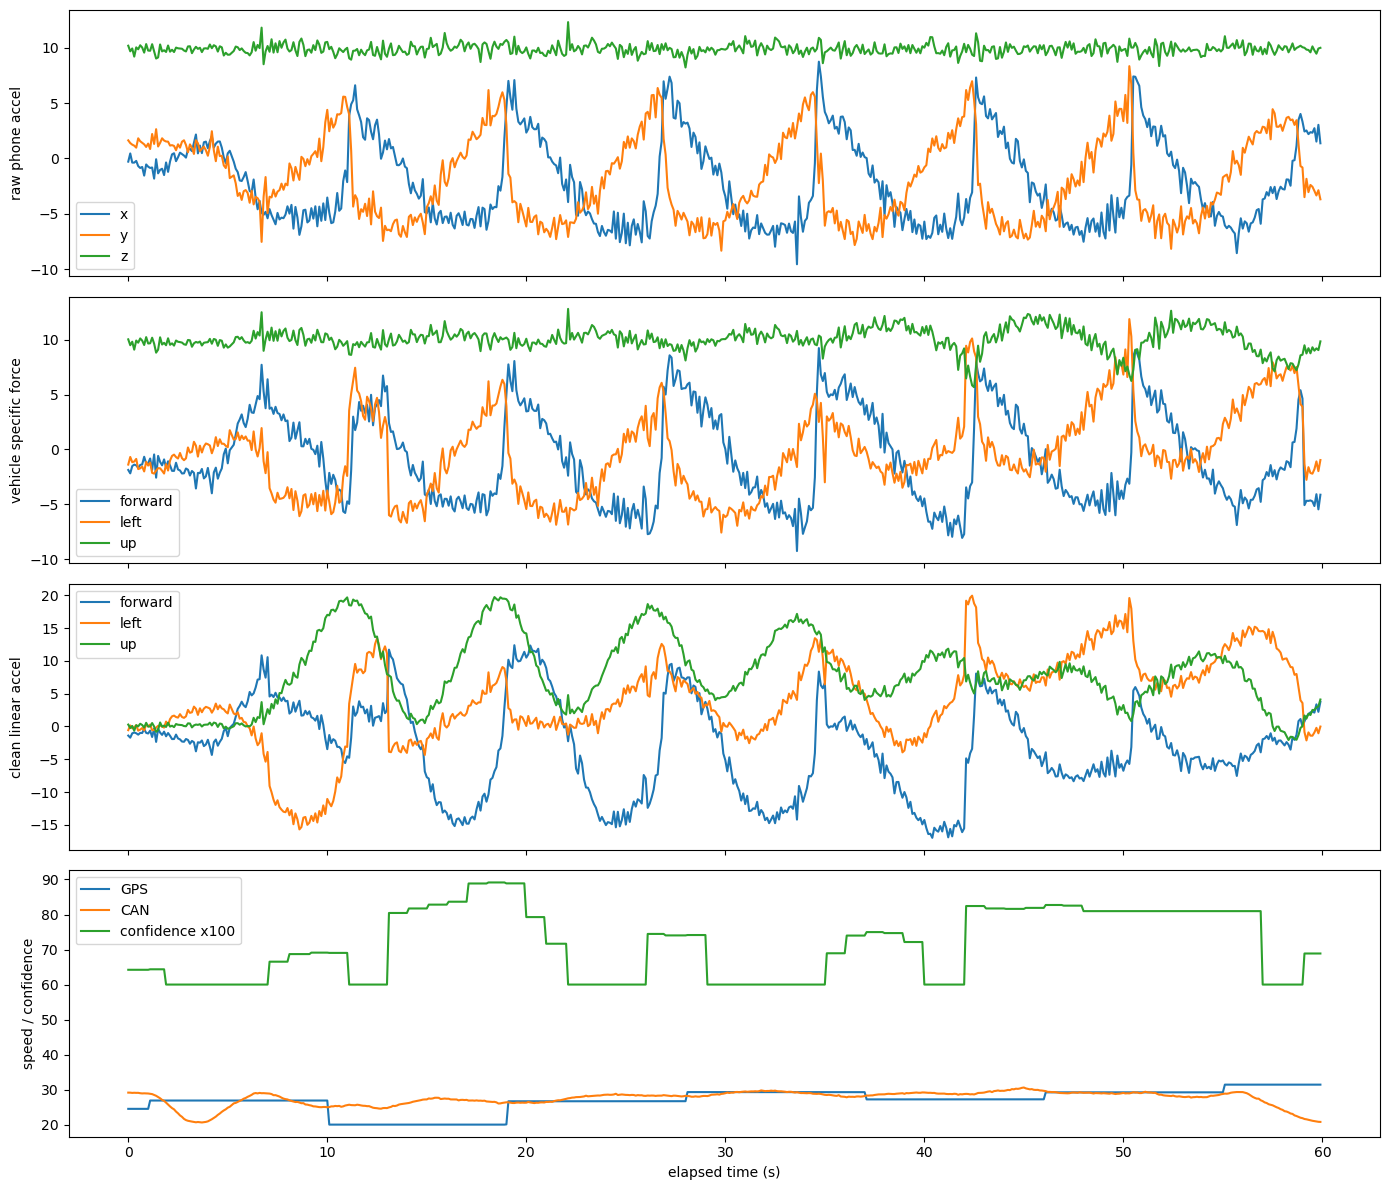

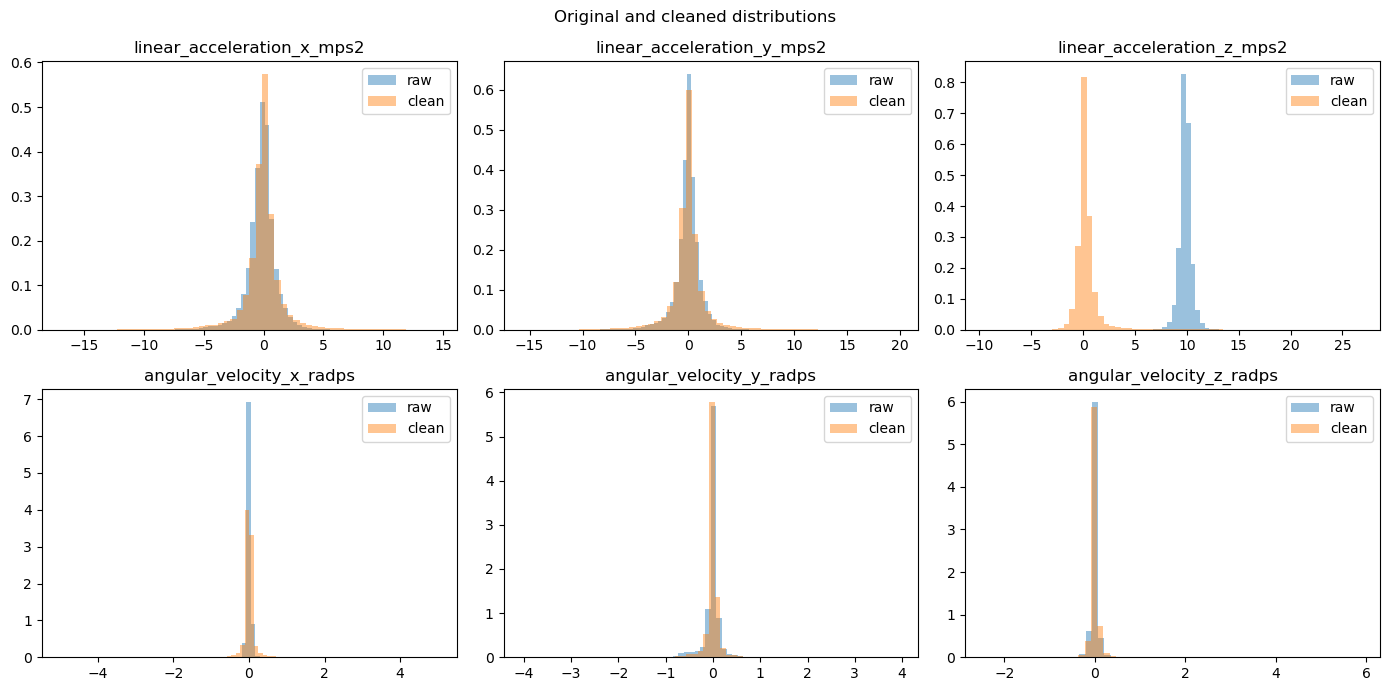

In [33]:
visual_journey = max(processed_journeys, key=lambda item: len(item.clean_imu))
comparison_table = pd.DataFrame({'timestamp_ns': visual_journey.timestamps_ns, **{name: visual_journey.raw_imu[:, i] for i, name in enumerate(RAW_FEATURE_NAMES)}, **{f'vehicle_before_gravity_{name}': visual_journey.vehicle_imu_before_gravity_removal[:, i] for i, name in enumerate(('ax','ay','az','gx','gy','gz'))}, **{f'clean_{name}': visual_journey.clean_imu[:, i] for i, name in enumerate(VELOCITY_MODEL_FEATURE_NAMES)}, 'gps_speed_kmh': visual_journey.gps_speed_mps * 3.6, 'can_target_kmh': visual_journey.target_speed_mps * 3.6, 'calibration_confidence': visual_journey.calibration_confidence})
display(comparison_table.head(12))
n = min(600, len(visual_journey.clean_imu)); elapsed = (visual_journey.timestamps_ns[:n] - visual_journey.timestamps_ns[0]) * 1e-9
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
axes[0].plot(elapsed, visual_journey.raw_imu[:n, :3]); axes[0].set_ylabel('raw phone accel'); axes[0].legend(['x','y','z'])
axes[1].plot(elapsed, visual_journey.vehicle_imu_before_gravity_removal[:n, :3]); axes[1].set_ylabel('vehicle specific force'); axes[1].legend(['forward','left','up'])
axes[2].plot(elapsed, visual_journey.clean_imu[:n, :3]); axes[2].set_ylabel('clean linear accel'); axes[2].legend(['forward','left','up'])
axes[3].plot(elapsed, visual_journey.gps_speed_mps[:n]*3.6, label='GPS'); axes[3].plot(elapsed, visual_journey.target_speed_mps[:n]*3.6, label='CAN'); axes[3].plot(elapsed, visual_journey.calibration_confidence[:n]*100, label='confidence x100')
axes[3].set_xlabel('elapsed time (s)'); axes[3].set_ylabel('speed / confidence'); axes[3].legend(); fig.tight_layout(); plt.show()
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for channel, axis in enumerate(axes.flat):
    axis.hist(visual_journey.raw_imu[:, channel], bins=60, density=True, alpha=.45, label='raw')
    axis.hist(visual_journey.clean_imu[:, channel], bins=60, density=True, alpha=.45, label='clean')
    axis.set_title(VELOCITY_MODEL_FEATURE_NAMES[channel]); axis.legend()
fig.suptitle('Original and cleaned distributions'); fig.tight_layout(); plt.show()

## 4. Physics preflight, then simulate GNSS blackouts

Before model training, the next cell checks two basic invariants: quiet vehicle-frame samples should become near-zero after gravity removal, and five-second integrated forward acceleration should roughly agree with five-second CAN speed change. If this preflight fails, inspect orientation, calibration, and gravity removal before spending hours on full hyperparameter search.

Once it passes, each example begins at a saved GNSS anchor; all later GNSS is hidden. Forward acceleration is integrated to 5, 10, 20, 30, 60, 90, and 120 seconds as a context feature and deterministic baseline. The learned target is the actual speed change since the anchor. Episodes never cross a journey, sensor gap, or quality reset.

In [34]:
import importlib
import matplotlib.pyplot as plt
import velocity_experiment

importlib.reload(velocity_experiment)

from velocity_experiment import preprocessing_physics_audit

In [35]:
physics_audit = preprocessing_physics_audit(processed_journeys, CONFIG)
display(physics_audit)

,journey_id,quiet_samples,quiet_clean_acceleration_median_mps2,clean_acceleration_p95_mps2,five_second_delta_v_mae_mps,preflight_pass
0,M,59784,0.687653,6.915322,4.490350,False
1,S1,30315,0.844330,5.524018,4.456077,False
2,S2,44887,0.731392,5.908978,4.699925,False
3,S3a,15809,0.646845,5.513250,4.020722,False
4,S3b,3957,0.871861,7.680338,4.354450,False
5,S3c,25172,0.692467,4.529920,3.802798,False
6,S4,54425,0.726944,4.995217,3.672375,False
7,Vfa01,2701,1.144143,6.383537,4.011920,False
8,Vfa02,16246,1.134949,5.363140,2.442181,False
9,Vta10,176,1.439876,6.885547,5.842680,False


In [36]:
physics_audit = preprocessing_physics_audit(processed_journeys, CONFIG)
display(physics_audit)
if SEARCH_PROFILE == 'full' and not bool(physics_audit.preflight_pass.all()):
    warning = ('Physics preflight failed: this full run is diagnostic only, '
               'not a production-model selection. Fix calibration before trusting its winner.')
    if not ALLOW_DIAGNOSTIC_FULL_RUN:
        raise RuntimeError(warning + ' Set ALLOW_DIAGNOSTIC_FULL_RUN=True to continue deliberately.')
    print('WARNING:', warning)
dataset = build_blackout_dataset(processed_journeys, CONFIG)
display(pd.DataFrame({'examples':[len(dataset)], 'journeys':[len(np.unique(dataset.journey_ids))], 'clean_shape':[str(dataset.clean_windows.shape)], 'raw_shape':[str(dataset.raw_windows.shape)], 'context':[', '.join(CONTEXT_FEATURE_NAMES)]}))
display(pd.Series(dataset.horizons_s).value_counts().sort_index().rename_axis('horizon_s').to_frame('examples'))
print('Post-anchor GNSS is not stored in any model input tensor.')

,journey_id,quiet_samples,quiet_clean_acceleration_median_mps2,clean_acceleration_p95_mps2,five_second_delta_v_mae_mps,preflight_pass
0,M,59784,0.687653,6.915322,4.490350,False
1,S1,30315,0.844330,5.524018,4.456077,False
2,S2,44887,0.731392,5.908978,4.699925,False
3,S3a,15809,0.646845,5.513250,4.020722,False
4,S3b,3957,0.871861,7.680338,4.354450,False
5,S3c,25172,0.692467,4.529920,3.802798,False
6,S4,54425,0.726944,4.995217,3.672375,False
7,Vfa01,2701,1.144143,6.383537,4.011920,False
8,Vfa02,16246,1.134949,5.363140,2.442181,False
9,Vta10,176,1.439876,6.885547,5.842680,False


,examples,journeys,clean_shape,raw_shape,context
0,45918,25,"(45918, 50, 6)","(45918, 50, 6)","anchor_speed_mps, integrated_speed_mps, second..."


,examples
horizon_s,
5,6712
10,6691
20,6652
30,6616
60,6514
90,6415
120,6318


Post-anchor GNSS is not stored in any model input tensor.


## 5. Freeze test journeys and create shared grouped folds

A deterministic grouped search chooses a test set representative in size, mean speed, high-speed share, and horizon mix. A journey-level allocator then balances five development folds by example count, speed categories, and horizon coverage while keeping every journey indivisible. RF, CNN, GRU, and the historical controls all reuse these exact indices.

In [11]:
development_index, test_index = choose_grouped_holdout(dataset, CONFIG)
development_groups, test_groups = set(dataset.journey_ids[development_index]), set(dataset.journey_ids[test_index])
assert development_groups.isdisjoint(test_groups)
cv_folds = make_grouped_cv_folds(dataset, development_index, CONFIG)
assert_group_isolation(dataset, cv_folds)
fold_audit = fold_audit_frame(dataset, development_index, test_index, cv_folds)
display(fold_audit)
print(f'Development={len(development_index):,}; frozen test={len(test_index):,}. Leakage checks passed.')

,partition,journeys,journey_count,examples,median_speed_kmh,high_speed_percent,horizons_s
0,frozen_test,"S3a, S3c, Vfa01, Vta30",4,6168,37.093166,14.477951,"5, 10, 20, 30, 60, 90, 120"
1,cv_validation_0,"M, Vta10, Vta8",3,7591,37.350899,7.232249,"5, 10, 20, 30, 60, 90, 120"
2,cv_validation_1,"S2, Vta14, Vta29",3,8255,30.949999,6.153846,"5, 10, 20, 30, 60, 90, 120"
3,cv_validation_2,"S3b, S4, Vta16, Vta22, Vta4",5,7607,34.671398,8.308137,"5, 10, 20, 30, 60, 90, 120"
4,cv_validation_3,"Vta17, Vta1a, Vta2, Vta26, Y1",5,7540,37.024998,7.586207,"5, 10, 20, 30, 60, 90, 120"
5,cv_validation_4,"S1, Vfa02, Vta21, Vta27, Vta28",5,8757,54.379799,46.488523,"5, 10, 20, 30, 60, 90, 120"


Development=39,750; frozen test=6,168. Leakage checks passed.


## 6. Features, grids, and grouped model selection

RF receives 52 IMU descriptors: mean, standard deviation, min, max, RMS, IQR, demeaned zero-crossing rate, and non-DC 0–3 Hz energy ratio per channel, plus mean/std of acceleration and gyro magnitudes. Five context values make 57 total. Anchor-delta neural models use weighted Huber loss in m/s. GRU search includes unidirectional and bidirectional fixed-window models. Bidirectionality is still causal because the entire window precedes the prediction time, but a selected bidirectional model must reprocess the window instead of carrying a simple streaming state. The CNN pads only its observed past.

The next cell is expensive in full mode. Candidate ranking uses mean macro-journey validation MAE; standard deviation exposes unstable candidates. The frozen test journeys remain untouched.

In [12]:
rf_check = rf_imu_features(dataset.clean_windows[:min(64, len(dataset))], CONFIG.sample_period_s)
assert rf_check.shape[1] == 52 and np.isfinite(rf_check).all()
RAW_GRU_PARAMETERS = {'hidden_size':64, 'num_layers':2, 'bidirectional':False, 'dropout':.2, 'learning_rate':1e-3}
CLEAN_CNN_PARAMETERS = {'conv_blocks':3, 'filter_base':32, 'kernel_size':3, 'dropout':.2, 'learning_rate':1e-3}
raw_gru_cv = tune_absolute_neural_baseline(label='raw_absolute_gru', family='gru', sequence=dataset.raw_windows, parameters=RAW_GRU_PARAMETERS, dataset=dataset, folds=cv_folds, config=CONFIG, device=DEVICE)
clean_cnn_cv = tune_absolute_neural_baseline(label='clean_absolute_cnn', family='cnn', sequence=dataset.clean_windows, parameters=CLEAN_CNN_PARAMETERS, dataset=dataset, folds=cv_folds, config=CONFIG, device=DEVICE)
anchor_delta_gru_cv = tune_neural_family('gru', dataset, cv_folds, CONFIG, DEVICE)
anchor_delta_cnn_cv = tune_neural_family('cnn', dataset, cv_folds, CONFIG, DEVICE)
anchor_delta_rf_cv = tune_random_forest(dataset, cv_folds, CONFIG)
selection_results = pd.concat([raw_gru_cv, clean_cnn_cv, anchor_delta_gru_cv, anchor_delta_cnn_cv, anchor_delta_rf_cv], ignore_index=True).sort_values('cv_macro_mae_mps').reset_index(drop=True)
selection_results['cv_macro_mae_kmh'] = selection_results.cv_macro_mae_mps * 3.6
selection_results['cv_macro_std_kmh'] = selection_results.cv_macro_mae_std_mps * 3.6
display(selection_results)

gru candidate 1/20, fold 1/5: 10.68 km/h
gru candidate 1/20, fold 2/5: 10.57 km/h
gru candidate 1/20, fold 3/5: 7.36 km/h
gru candidate 1/20, fold 4/5: 9.62 km/h
gru candidate 1/20, fold 5/5: 9.67 km/h
gru candidate 2/20, fold 1/5: 10.65 km/h
gru candidate 2/20, fold 2/5: 10.67 km/h
gru candidate 2/20, fold 3/5: 7.10 km/h
gru candidate 2/20, fold 4/5: 9.70 km/h
gru candidate 2/20, fold 5/5: 10.12 km/h
gru candidate 3/20, fold 1/5: 11.29 km/h
gru candidate 3/20, fold 2/5: 10.52 km/h
gru candidate 3/20, fold 3/5: 7.43 km/h
gru candidate 3/20, fold 4/5: 10.12 km/h
gru candidate 3/20, fold 5/5: 10.21 km/h
gru candidate 4/20, fold 1/5: 10.70 km/h
gru candidate 4/20, fold 2/5: 10.56 km/h
gru candidate 4/20, fold 3/5: 7.26 km/h
gru candidate 4/20, fold 4/5: 9.83 km/h
gru candidate 4/20, fold 5/5: 9.93 km/h
gru candidate 5/20, fold 1/5: 10.52 km/h
gru candidate 5/20, fold 2/5: 10.43 km/h
gru candidate 5/20, fold 3/5: 7.59 km/h
gru candidate 5/20, fold 4/5: 9.74 km/h
gru candidate 5/20, fold 5/

KeyboardInterrupt: 

In [14]:
selection_results = pd.concat(
    [
        raw_gru_cv,
        clean_cnn_cv,
        anchor_delta_gru_cv,
        anchor_delta_cnn_cv,
    ],
    ignore_index=True,
).sort_values("cv_macro_mae_mps").reset_index(drop=True)

selection_results["cv_macro_mae_kmh"] = selection_results.cv_macro_mae_mps * 3.6
selection_results["cv_macro_std_kmh"] = selection_results.cv_macro_mae_std_mps * 3.6
display(selection_results)

,model,candidate_id,parameters,cv_macro_mae_mps,cv_macro_mae_std_mps,fold_best_epochs,training_s,cv_macro_mae_kmh,cv_macro_std_kmh
0,anchor_delta_cnn,17,"{'learning_rate': 0.001, 'kernel_size': 5, 'fi...",2.620417,0.437270,"[40, 16, 32, 15, 13]",366.481656,9.433502,1.574174
1,anchor_delta_gru,15,"{'num_layers': 2, 'learning_rate': 0.0003, 'hi...",2.625395,0.373926,"[23, 17, 16, 8, 5]",422.690286,9.451420,1.346134
2,anchor_delta_cnn,4,"{'learning_rate': 0.001, 'kernel_size': 3, 'fi...",2.628148,0.403286,"[48, 10, 16, 54, 4]",398.844753,9.461334,1.451830
3,anchor_delta_cnn,1,"{'learning_rate': 0.0003, 'kernel_size': 5, 'f...",2.629743,0.391551,"[35, 39, 37, 35, 8]",447.327267,9.467076,1.409585
4,anchor_delta_cnn,9,"{'learning_rate': 0.001, 'kernel_size': 3, 'fi...",2.631802,0.415660,"[22, 6, 16, 19, 2]",333.708713,9.474486,1.496375
5,anchor_delta_cnn,2,"{'learning_rate': 0.001, 'kernel_size': 3, 'fi...",2.634819,0.373675,"[34, 20, 9, 17, 9]",374.707627,9.485348,1.345231
6,anchor_delta_cnn,6,"{'learning_rate': 0.001, 'kernel_size': 5, 'fi...",2.635074,0.389040,"[7, 13, 11, 7, 3]",282.460314,9.486266,1.400544
7,anchor_delta_cnn,11,"{'learning_rate': 0.001, 'kernel_size': 3, 'fi...",2.639102,0.400445,"[29, 3, 10, 15, 3]",356.717976,9.500766,1.441604
8,anchor_delta_cnn,10,"{'learning_rate': 0.001, 'kernel_size': 3, 'fi...",2.642590,0.388680,"[29, 8, 9, 15, 11]",343.902971,9.513324,1.399248
9,anchor_delta_cnn,8,"{'learning_rate': 0.001, 'kernel_size': 3, 'fi...",2.644634,0.407496,"[32, 7, 24, 43, 2]",377.547403,9.520683,1.466986


## 7. Final refit and one frozen-test evaluation

Neural winners are refitted on all development journeys for the median best epoch found in CV. Constant-anchor and pure-integration baselines need no fitting. The test set is opened once, after all choices are fixed.

In [ ]:
def winner(model_name):
    return selection_results.loc[
        selection_results.model == model_name
    ].iloc[0]

neural_labels = (
    "raw_absolute_gru",
    "clean_absolute_cnn",
    "anchor_delta_gru",
    "anchor_delta_cnn",
)

# Preserve work if the previous RF-containing cell got as far as fitting
# neural models before failing at the missing RF result.
predictions = globals().get("predictions", {})
trained_models = globals().get("trained_models", {})
trained_scalers = globals().get("trained_scalers", {})

# Deterministic non-ML baselines remain important comparison points.
predictions.setdefault(
    "constant_anchor",
    np.maximum(0.0, dataset.context[test_index, 0]),
)
predictions.setdefault(
    "pure_integration",
    np.maximum(0.0, dataset.context[test_index, 1]),
)

absolute_models = (
    ("raw_absolute_gru", "gru", dataset.raw_windows, RAW_GRU_PARAMETERS),
    ("clean_absolute_cnn", "cnn", dataset.clean_windows, CLEAN_CNN_PARAMETERS),
)

for label, family, sequence, parameters in absolute_models:
    if label not in predictions:
        row = winner(label)
        epochs = max(1, int(round(np.median(row.fold_best_epochs))))
        model, scalers = fit_final_absolute_neural(
            family=family,
            sequence=sequence,
            parameters=parameters,
            epochs=epochs,
            dataset=dataset,
            development_index=development_index,
            config=CONFIG,
            device=DEVICE,
        )
        trained_models[label] = model
        trained_scalers[label] = scalers
        predictions[label] = predict_final_absolute_neural(
            model, scalers, sequence, test_index, CONFIG, DEVICE
        )

for family in ("gru", "cnn"):
    label = f"anchor_delta_{family}"
    if label not in predictions:
        row = winner(label)
        epochs = max(1, int(round(np.median(row.fold_best_epochs))))
        model, scalers = fit_final_neural(
            family,
            row.parameters,
            epochs,
            dataset,
            development_index,
            CONFIG,
            DEVICE,
        )
        trained_models[label] = model
        trained_scalers[label] = scalers
        predictions[label] = predict_final_neural(
            model, scalers, dataset, test_index, CONFIG, DEVICE
        )

comparison = pd.DataFrame(
    [
        {
            "model": name,
            **regression_metrics(
                dataset.target_speed_mps[test_index],
                prediction,
                dataset.journey_ids[test_index],
            ),
        }
        for name, prediction in predictions.items()
    ]
).sort_values("macro_journey_mae_mps").reset_index(drop=True)

display(comparison)

IndexError: single positional indexer is out-of-bounds

In [13]:
error_detail = detailed_error_frame(dataset, test_index, predictions)
horizon_errors = error_detail[error_detail.slice == 'horizon']
fig, axes = plt.subplots(1, 2, figsize=(15,5))
for name, rows in horizon_errors.groupby('model'): axes[0].plot(rows.value, rows.macro_journey_mae_kmh, marker='o', label=name)
axes[0].set(xlabel='seconds since GNSS anchor', ylabel='macro journey MAE (km/h)', title='Error growth during GNSS loss'); axes[0].legend(fontsize=8)
axes[1].bar(comparison.model, comparison.macro_journey_mae_kmh); axes[1].set(ylabel='macro journey MAE (km/h)', title='Frozen-test comparison'); axes[1].tick_params(axis='x', rotation=45)
fig.tight_layout(); plt.show()
best_model = comparison.iloc[0].model; best_horizon = horizon_errors[horizon_errors.model == best_model].set_index('value')
targets = {30:5., 60:8., 120:12.}
acceptance = pd.DataFrame([{'horizon_s':h, 'target_mae_kmh':target, 'observed_mae_kmh':float(best_horizon.loc[h,'macro_journey_mae_kmh']), 'passed':bool(best_horizon.loc[h,'macro_journey_mae_kmh'] <= target)} for h, target in targets.items() if h in best_horizon.index])
display(acceptance)

NameError: name 'predictions' is not defined

## 8. Latency and reproducible artifacts

Timings use batch size one after warm-up and report median and p95. Model-only isolates neural execution. Feature-plus-model includes scaling and residual composition. A separate full-journey replay estimates amortized deterministic preprocessing per incoming sample; actual phone hardware must still be benchmarked.

In [19]:
latency_rows = []; sample_index = int(test_index[0])
for label in ('anchor_delta_gru','anchor_delta_cnn'):
    model, scalers = trained_models[label], trained_scalers[label]
    xs = torch.from_numpy(transform_sequence(scalers.sequence, dataset.clean_windows[[sample_index]])).to(DEVICE)
    cs = torch.from_numpy(transform_context(scalers.context, dataset.context[[sample_index]])).to(DEVICE); model.eval()
    latency_rows.append({'model':label, 'stage':'model_only', **measure_latency_ms(lambda model=model: model(xs,cs), CONFIG, DEVICE)})
    latency_rows.append({'model':label, 'stage':'feature_plus_model', **measure_latency_ms(lambda label=label: predict_final_neural(trained_models[label], trained_scalers[label], dataset, np.asarray([sample_index]), CONFIG, DEVICE), CONFIG, DEVICE)})
latency_frame = pd.DataFrame(latency_rows); display(latency_frame)

,model,stage,median_ms,p95_ms
0,anchor_delta_gru,model_only,0.54010,2.142390
1,anchor_delta_gru,feature_plus_model,0.77340,1.083295
2,anchor_delta_cnn,model_only,0.79635,1.418625
3,anchor_delta_cnn,feature_plus_model,1.09945,1.965810


In [22]:
keep_models = (
    "constant_anchor",
    "pure_integration",
    "raw_absolute_gru",
    "clean_absolute_cnn",
    "anchor_delta_gru",
    "anchor_delta_cnn",
)

missing_models = [
    label for label in keep_models
    if label not in predictions
]
assert not missing_models, (
    f"Missing predictions: {missing_models}. "
    "Run the neural-only final-refit cell first."
)

# Explicitly exclude RF, including any stale result from an earlier attempt.
predictions = {
    label: predictions[label]
    for label in keep_models
}

comparison = pd.DataFrame(
    [
        {
            "model": name,
            **regression_metrics(
                dataset.target_speed_mps[test_index],
                prediction,
                dataset.journey_ids[test_index],
            ),
        }
        for name, prediction in predictions.items()
    ]
).sort_values("macro_journey_mae_mps").reset_index(drop=True)

display(comparison)

NameError: name 'predictions' is not defined

In [21]:
comparison = pd.DataFrame(
    [
        {
            "model": name,
            **regression_metrics(
                dataset.target_speed_mps[test_index],
                prediction,
                dataset.journey_ids[test_index],
            ),
        }
        for name, prediction in predictions.items()
        if name != "anchor_delta_random_forest"
    ]
).sort_values("macro_journey_mae_mps").reset_index(drop=True)

display(comparison)

NameError: name 'predictions' is not defined

In [23]:
error_detail = detailed_error_frame(dataset, test_index, predictions)
horizon_errors = error_detail[error_detail.slice == "horizon"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for name, rows in horizon_errors.groupby("model"):
    axes[0].plot(
        rows.value,
        rows.macro_journey_mae_kmh,
        marker="o",
        label=name,
    )

axes[0].set(
    xlabel="seconds since GNSS anchor",
    ylabel="macro journey MAE (km/h)",
    title="Error growth during GNSS loss",
)
axes[0].legend(fontsize=8)

axes[1].bar(comparison.model, comparison.macro_journey_mae_kmh)
axes[1].set(
    ylabel="macro journey MAE (km/h)",
    title="Frozen-test comparison",
)
axes[1].tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

best_model = comparison.iloc[0].model
best_horizon = horizon_errors[
    horizon_errors.model == best_model
].set_index("value")

targets = {30: 5.0, 60: 8.0, 120: 12.0}
acceptance = pd.DataFrame(
    [
        {
            "horizon_s": horizon,
            "target_mae_kmh": target,
            "observed_mae_kmh": float(
                best_horizon.loc[horizon, "macro_journey_mae_kmh"]
            ),
            "passed": bool(
                best_horizon.loc[horizon, "macro_journey_mae_kmh"] <= target
            ),
        }
        for horizon, target in targets.items()
        if horizon in best_horizon.index
    ]
)

display(acceptance)

NameError: name 'test_index' is not defined

In [24]:
latency_rows = []
sample_index = int(test_index[0])

for label in ("anchor_delta_gru", "anchor_delta_cnn"):
    model = trained_models[label]
    scalers = trained_scalers[label]

    xs = torch.from_numpy(
        transform_sequence(
            scalers.sequence,
            dataset.clean_windows[[sample_index]],
        )
    ).to(DEVICE)

    cs = torch.from_numpy(
        transform_context(
            scalers.context,
            dataset.context[[sample_index]],
        )
    ).to(DEVICE)

    model.eval()

    latency_rows.append(
        {
            "model": label,
            "stage": "model_only",
            **measure_latency_ms(
                lambda model=model: model(xs, cs),
                CONFIG,
                DEVICE,
            ),
        }
    )

    latency_rows.append(
        {
            "model": label,
            "stage": "feature_plus_model",
            **measure_latency_ms(
                lambda label=label: predict_final_neural(
                    trained_models[label],
                    trained_scalers[label],
                    dataset,
                    np.asarray([sample_index]),
                    CONFIG,
                    DEVICE,
                ),
                CONFIG,
                DEVICE,
            ),
        }
    )

latency_frame = pd.DataFrame(latency_rows)
display(latency_frame)

NameError: name 'test_index' is not defined

In [26]:
selection_results.to_csv(ARTIFACT_DIR / "cv_selection.csv", index=False)
comparison.to_csv(ARTIFACT_DIR / "frozen_test_comparison.csv", index=False)
error_detail.to_csv(ARTIFACT_DIR / "error_by_horizon_and_speed.csv", index=False)
fold_audit.to_csv(ARTIFACT_DIR / "fold_audit.csv", index=False)
audit_frame.to_csv(ARTIFACT_DIR / "preprocessing_audit.csv", index=False)
skipped_frame.to_csv(ARTIFACT_DIR / "skipped_journeys.csv", index=False)
latency_frame.to_csv(ARTIFACT_DIR / "latency.csv", index=False)
acceptance.to_csv(ARTIFACT_DIR / "acceptance_targets.csv", index=False)

prediction_frame = pd.DataFrame(
    {
        "journey_id": dataset.journey_ids[test_index],
        "anchor_timestamp_ns": dataset.anchor_timestamps_ns[test_index],
        "end_timestamp_ns": dataset.end_timestamps_ns[test_index],
        "horizon_s": dataset.horizons_s[test_index],
        "anchor_speed_mps": dataset.context[test_index, 0],
        "integrated_speed_mps": dataset.context[test_index, 1],
        "actual_speed_mps": dataset.target_speed_mps[test_index],
        **{
            f"{name}_prediction_mps": value
            for name, value in predictions.items()
        },
    }
)
prediction_frame.to_csv(
    ARTIFACT_DIR / "frozen_test_predictions.csv",
    index=False,
)

for label in (
    "raw_absolute_gru",
    "clean_absolute_cnn",
    "anchor_delta_gru",
    "anchor_delta_cnn",
):
    torch.save(
        {
            "model_name": label,
            "state_dict": trained_models[label].state_dict(),
            "sequence_scaler": trained_scalers[label].sequence,
            "context_scaler": trained_scalers[label].context,
            "feature_names": list(VELOCITY_MODEL_FEATURE_NAMES),
            "context_names": (
                list(CONTEXT_FEATURE_NAMES)
                if label.startswith("anchor_delta_")
                else []
            ),
            "target_unit": "m/s",
        },
        ARTIFACT_DIR / f"{label}.pt",
    )

best_anchored_neural = comparison.loc[
    comparison.model.isin(("anchor_delta_gru", "anchor_delta_cnn"))
].iloc[0].model

manifest = {
    "config": config_dict(CONFIG),
    "development_journeys": sorted(development_groups),
    "test_journeys": sorted(test_groups),
    "feature_names": list(VELOCITY_MODEL_FEATURE_NAMES),
    "context_names": list(CONTEXT_FEATURE_NAMES),
    "target_unit": "m/s",
    "selection_metric": "five-fold grouped macro-journey MAE in m/s",
    "best_anchored_neural_model_on_frozen_test": best_anchored_neural,
    "evaluated_models": list(comparison.model),
    "gnss_policy": "only blackout-start speed is exposed",
    "random_forest_status": "excluded: CV was intentionally interrupted; no RF artifact was trained or exported",
}

(ARTIFACT_DIR / "manifest.json").write_text(
    json.dumps(manifest, indent=2),
    encoding="utf-8",
)

print(f"Saved neural-only experiment bundle to {ARTIFACT_DIR}")

Saved neural-only experiment bundle to E:\dead reckoning\artifacts\anchored_velocity_comparison


## Interpretation

Choose the candidate using development CV before reading frozen-test results. The anchored model must beat both constant-speed hold and pure integration; merely beating the old absolute-speed GRU is insufficient. Judge the 30, 60, and 120 second macro-journey targets separately. If a gate fails, inspect journey, speed-bin, calibration, and horizon diagnostics before widening the neural search.

This notebook does not train uncertainty. Once a velocity model passes accuracy and latency checks, its predicted speed, anchor age, model identity, calibration confidence, and sensor-quality context become inputs to the separately evaluated uncertainty engine.

In [28]:
# Build the blackout dataset and reuse the original grouped journey split.
# No velocity model is trained or evaluated here.

dataset = build_blackout_dataset(processed_journeys, CONFIG)

development_index, test_index = choose_grouped_holdout(dataset, CONFIG)
development_groups = set(dataset.journey_ids[development_index])
test_groups = set(dataset.journey_ids[test_index])

assert development_groups.isdisjoint(test_groups)

cv_folds = make_grouped_cv_folds(dataset, development_index, CONFIG)
assert_group_isolation(dataset, cv_folds)

print(
    f"Development journeys: {len(development_groups)} | "
    f"frozen-test journeys: {len(test_groups)} | "
    f"CV folds: {len(cv_folds)}"
)

NameError: name 'processed_journeys' is not defined

In [37]:
# Stateful, anchor-to-blackout GRU experiment.
# This is a separate candidate family. The existing 5-second ONNX GRU remains
# the baseline and runtime fallback until this experiment wins fairly.

from collections import Counter
from dataclasses import dataclass
import copy
import json

import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import ParameterSampler
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.nn import functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.utils.data import DataLoader, Dataset

# These variables must already exist from the earlier notebook cells.
assert processed_journeys
assert development_groups.isdisjoint(test_groups)
assert len(cv_folds) == CONFIG.cv_folds

STATEFUL_SEARCH_PROFILE = "smoke"  # First validate one candidate. Change to "full" later.
STATEFUL_CANDIDATE_COUNT = 20
STATEFUL_MAX_EPOCHS = 150
STATEFUL_EARLY_STOPPING_PATIENCE = 15
STATEFUL_BATCH_SIZE = 4  # Full 120-second sequences are much larger than 5-second windows.
STATEFUL_LABEL_PERIOD_S = 1.0

# Six cleaned IMU channels plus five causal values available at every timestep.
STATEFUL_FEATURE_NAMES = (
    *VELOCITY_MODEL_FEATURE_NAMES,
    "anchor_speed_mps",
    "integrated_speed_mps",
    "seconds_since_anchor",
    "running_mean_calibration_confidence",
    "running_minimum_calibration_confidence",
)

STATEFUL_ARTIFACT_DIR = ARTIFACT_DIR / "stateful_anchor_delta_gru"
STATEFUL_ARTIFACT_DIR.mkdir(exist_ok=True)

print(
    f"Stateful search: {STATEFUL_SEARCH_PROFILE}; "
    f"device: {DEVICE}; "
    f"features: {len(STATEFUL_FEATURE_NAMES)}"
)

NameError: name 'development_groups' is not defined

In [27]:
@dataclass(frozen=True)
class StatefulBlackoutSequence:
    """One causal sequence beginning at a trustworthy GNSS anchor."""

    journey_id: str
    anchor_timestamp_ns: int
    anchor_speed_mps: float

    # Shape: [elapsed samples, 11]
    features: np.ndarray

    # Speed change from anchor at every timestep.
    target_delta_mps: np.ndarray

    # Training supervises every second; horizon mask is only for fair comparison.
    training_mask: np.ndarray
    evaluation_mask: np.ndarray


def build_stateful_blackout_sequences(
    journeys,
    *,
    config,
    permitted_journeys: set[str],
) -> list[StatefulBlackoutSequence]:
    """Build anchor-to-blackout sequences without reading future GNSS inputs."""

    sample_period_s = config.sample_period_s
    steps_per_training_label = round(STATEFUL_LABEL_PERIOD_S / sample_period_s)
    horizon_steps = {
        round(horizon_s / sample_period_s): horizon_s
        for horizon_s in config.blackout_horizons_s
    }
    minimum_horizon_steps = min(horizon_steps)
    maximum_horizon_steps = max(horizon_steps)
    anchor_stride_steps = max(1, round(config.anchor_stride_s / sample_period_s))

    sequences: list[StatefulBlackoutSequence] = []

    for journey in journeys:
        if journey.journey_id not in permitted_journeys:
            continue

        for segment_id in np.unique(journey.segment_ids):
            segment_indices = np.flatnonzero(journey.segment_ids == segment_id)
            segment_start = int(segment_indices[0])
            segment_end = int(segment_indices[-1])

            for anchor_index in range(
                segment_start,
                segment_end + 1,
                anchor_stride_steps,
            ):
                end_index = min(
                    anchor_index + maximum_horizon_steps,
                    segment_end,
                )
                if end_index - anchor_index < minimum_horizon_steps:
                    continue

                anchor_speed_mps = float(journey.gps_speed_mps[anchor_index])
                if not np.isfinite(anchor_speed_mps) or anchor_speed_mps < 0.0:
                    continue

                clean_imu = np.asarray(
                    journey.clean_imu[anchor_index : end_index + 1],
                    dtype=np.float32,
                )
                target_speed_mps = np.asarray(
                    journey.target_speed_mps[anchor_index : end_index + 1],
                    dtype=np.float32,
                )
                confidence = np.asarray(
                    journey.calibration_confidence[anchor_index : end_index + 1],
                    dtype=np.float32,
                )

                if (
                    not np.isfinite(clean_imu).all()
                    or not np.isfinite(target_speed_mps).all()
                    or not np.isfinite(confidence).all()
                ):
                    continue

                steps = np.arange(len(clean_imu), dtype=np.float32)
                acceleration = clean_imu[:, 0]

                # Causal trapezoidal integration from the anchor. At t=0,
                # integrated speed equals the trusted GNSS anchor speed.
                acceleration_delta = np.zeros(len(clean_imu), dtype=np.float32)
                acceleration_delta[1:] = np.cumsum(
                    0.5
                    * (acceleration[1:] + acceleration[:-1])
                    * sample_period_s,
                    dtype=np.float32,
                )
                integrated_speed_mps = np.maximum(
                    0.0,
                    anchor_speed_mps + acceleration_delta,
                ).astype(np.float32)

                running_mean_confidence = (
                    np.cumsum(confidence, dtype=np.float32)
                    / (steps + 1.0)
                )
                running_minimum_confidence = np.minimum.accumulate(confidence)

                features = np.column_stack(
                    (
                        clean_imu,
                        np.full(len(clean_imu), anchor_speed_mps, dtype=np.float32),
                        integrated_speed_mps,
                        steps * sample_period_s,
                        running_mean_confidence,
                        running_minimum_confidence,
                    )
                ).astype(np.float32)

                training_mask = (
                    (steps.astype(int) % steps_per_training_label == 0)
                    & (steps > 0)
                )
                evaluation_mask = np.zeros(len(clean_imu), dtype=bool)
                for horizon_step in horizon_steps:
                    if horizon_step < len(clean_imu):
                        evaluation_mask[horizon_step] = True

                # A sequence must contain at least one standard horizon.
                if not evaluation_mask.any():
                    continue

                sequences.append(
                    StatefulBlackoutSequence(
                        journey_id=journey.journey_id,
                        anchor_timestamp_ns=int(
                            journey.timestamps_ns[anchor_index]
                        ),
                        anchor_speed_mps=anchor_speed_mps,
                        features=features,
                        target_delta_mps=(
                            target_speed_mps - anchor_speed_mps
                        ).astype(np.float32),
                        training_mask=training_mask,
                        evaluation_mask=evaluation_mask,
                    )
                )

    return sequences


# Crucially, construct development sequences only. Frozen-test journeys are not
# even materialized in this cell.
stateful_sequences = build_stateful_blackout_sequences(
    processed_journeys,
    config=CONFIG,
    permitted_journeys=development_groups,
)

assert stateful_sequences
assert set(item.journey_id for item in stateful_sequences).isdisjoint(test_groups)

stateful_sequence_frame = pd.DataFrame(
    {
        "journey_id": [item.journey_id for item in stateful_sequences],
        "length_s": [
            (len(item.features) - 1) * CONFIG.sample_period_s
            for item in stateful_sequences
        ],
        "supervised_seconds": [
            int(item.training_mask.sum())
            for item in stateful_sequences
        ],
        "evaluated_horizons": [
            int(item.evaluation_mask.sum())
            for item in stateful_sequences
        ],
    }
)

display(
    stateful_sequence_frame.groupby("journey_id").agg(
        sequences=("journey_id", "size"),
        median_length_s=("length_s", "median"),
        maximum_length_s=("length_s", "max"),
    )
)
print(f"Development-only stateful sequences: {len(stateful_sequences):,}")

,sequences,median_length_s,maximum_length_s
journey_id,,,
M,1057,120.0,120.0
S1,516,120.0,120.0
S2,936,120.0,120.0
S3b,66,120.0,120.0
S4,914,120.0,120.0
Vfa02,673,120.0,120.0
Vta10,14,71.2,120.0
Vta14,27,120.0,120.0
Vta16,112,120.0,120.0


Development-only stateful sequences: 5,812


In [28]:
stateful_folds: list[tuple[np.ndarray, np.ndarray]] = []

stateful_journey_ids = np.asarray(
    [item.journey_id for item in stateful_sequences],
    dtype=str,
)

for original_train, original_validation in cv_folds:
    train_journeys = set(dataset.journey_ids[original_train])
    validation_journeys = set(dataset.journey_ids[original_validation])

    train_indices = np.flatnonzero(
        np.isin(stateful_journey_ids, list(train_journeys))
    )
    validation_indices = np.flatnonzero(
        np.isin(stateful_journey_ids, list(validation_journeys))
    )

    assert len(train_indices) > 0
    assert len(validation_indices) > 0
    assert set(stateful_journey_ids[train_indices]).isdisjoint(
        stateful_journey_ids[validation_indices]
    )

    stateful_folds.append((train_indices, validation_indices))

stateful_fold_audit = pd.DataFrame(
    [
        {
            "fold": fold_id + 1,
            "train_journeys": ", ".join(
                sorted(set(stateful_journey_ids[train_index]))
            ),
            "validation_journeys": ", ".join(
                sorted(set(stateful_journey_ids[validation_index]))
            ),
            "train_sequences": len(train_index),
            "validation_sequences": len(validation_index),
        }
        for fold_id, (train_index, validation_index)
        in enumerate(stateful_folds)
    ]
)

display(stateful_fold_audit)

,fold,train_journeys,validation_journeys,train_sequences,validation_sequences
0,1,"S1, S2, S3b, S4, Vfa02, Vta14, Vta16, Vta17, V...","M, Vta10, Vta8",4705,1107
1,2,"M, S1, S3b, S4, Vfa02, Vta10, Vta16, Vta17, Vt...","S2, Vta14, Vta29",4614,1198
2,3,"M, S1, S2, Vfa02, Vta10, Vta14, Vta17, Vta1a, ...","S3b, S4, Vta16, Vta22, Vta4",4688,1124
3,4,"M, S1, S2, S3b, S4, Vfa02, Vta10, Vta14, Vta16...","Vta17, Vta1a, Vta2, Vta26, Y1",4701,1111
4,5,"M, S2, S3b, S4, Vta10, Vta14, Vta16, Vta17, Vt...","S1, Vfa02, Vta21, Vta27, Vta28",4540,1272


In [29]:
class StatefulSequenceDataset(Dataset):
    """Apply a fold-fitted scaler to one collection of full blackout sequences."""

    def __init__(
        self,
        sequences: list[StatefulBlackoutSequence],
        sequence_indices: np.ndarray,
        scaler: StandardScaler,
    ) -> None:
        self._sequences = sequences
        self._indices = np.asarray(sequence_indices, dtype=np.int64)
        self._scaler = scaler

        journey_counts = Counter(
            sequences[index].journey_id for index in self._indices
        )
        raw_weights = np.asarray(
            [
                1.0 / journey_counts[sequences[index].journey_id]
                for index in self._indices
            ],
            dtype=np.float32,
        )
        self._weights = raw_weights / raw_weights.mean()

    def __len__(self) -> int:
        return len(self._indices)

    def __getitem__(self, position: int) -> dict[str, object]:
        sequence_index = int(self._indices[position])
        item = self._sequences[sequence_index]

        return {
            "sequence_index": sequence_index,
            "journey_id": item.journey_id,
            "anchor_timestamp_ns": item.anchor_timestamp_ns,
            "anchor_speed_mps": item.anchor_speed_mps,
            "features": self._scaler.transform(item.features).astype(np.float32),
            "target_delta_mps": item.target_delta_mps,
            "training_mask": item.training_mask,
            "evaluation_mask": item.evaluation_mask,
            "weight": float(self._weights[position]),
        }


def fit_stateful_feature_scaler(
    sequences: list[StatefulBlackoutSequence],
    sequence_indices: np.ndarray,
) -> StandardScaler:
    """Fit feature normalization only on the fold's training journeys."""

    training_rows = np.concatenate(
        [sequences[index].features for index in sequence_indices],
        axis=0,
    )
    return StandardScaler().fit(training_rows)


def collate_stateful_sequences(
    items: list[dict[str, object]],
) -> dict[str, object]:
    """Pad a batch while preserving masks, lengths, and anchor metadata."""

    lengths = torch.tensor(
        [len(item["features"]) for item in items],
        dtype=torch.long,
    )
    maximum_length = int(lengths.max().item())
    batch_size = len(items)
    feature_count = len(STATEFUL_FEATURE_NAMES)

    features = torch.zeros(
        (batch_size, maximum_length, feature_count),
        dtype=torch.float32,
    )
    targets = torch.zeros((batch_size, maximum_length), dtype=torch.float32)
    training_mask = torch.zeros(
        (batch_size, maximum_length),
        dtype=torch.bool,
    )
    evaluation_mask = torch.zeros(
        (batch_size, maximum_length),
        dtype=torch.bool,
    )

    for row, item in enumerate(items):
        length = int(lengths[row].item())
        features[row, :length] = torch.from_numpy(item["features"])
        targets[row, :length] = torch.from_numpy(item["target_delta_mps"])
        training_mask[row, :length] = torch.from_numpy(item["training_mask"])
        evaluation_mask[row, :length] = torch.from_numpy(item["evaluation_mask"])

    return {
        "sequence_indices": torch.tensor(
            [item["sequence_index"] for item in items],
            dtype=torch.long,
        ),
        "journey_ids": [item["journey_id"] for item in items],
        "anchor_timestamps_ns": torch.tensor(
            [item["anchor_timestamp_ns"] for item in items],
            dtype=torch.long,
        ),
        "anchor_speeds_mps": torch.tensor(
            [item["anchor_speed_mps"] for item in items],
            dtype=torch.float32,
        ),
        "features": features,
        "targets": targets,
        "training_mask": training_mask,
        "evaluation_mask": evaluation_mask,
        "lengths": lengths,
        "weights": torch.tensor(
            [item["weight"] for item in items],
            dtype=torch.float32,
        ),
    }


def make_stateful_loader(
    sequences: list[StatefulBlackoutSequence],
    sequence_indices: np.ndarray,
    scaler: StandardScaler,
    *,
    shuffle: bool,
) -> DataLoader:
    """Create deterministic batches of variable-length full blackout sequences."""

    return DataLoader(
        StatefulSequenceDataset(sequences, sequence_indices, scaler),
        batch_size=STATEFUL_BATCH_SIZE,
        shuffle=shuffle,
        num_workers=0,
        collate_fn=collate_stateful_sequences,
    )


class StatefulAnchorDeltaGru(nn.Module):
    """Causal unidirectional GRU that predicts delta-v at every elapsed step."""

    def __init__(
        self,
        *,
        feature_count: int,
        hidden_size: int,
        num_layers: int,
        dropout: float,
    ) -> None:
        super().__init__()

        self.gru = nn.GRU(
            input_size=feature_count,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False,  # Required for actual streaming deployment.
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(
        self,
        features: torch.Tensor,
        lengths: torch.Tensor,
        hidden_state: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """Return one delta-v prediction per observed timestep and final state."""

        packed = pack_padded_sequence(
            features,
            lengths.detach().to("cpu"),
            batch_first=True,
            enforce_sorted=False,
        )
        packed_output, final_hidden_state = self.gru(
            packed,
            hidden_state,
        )
        output, _ = pad_packed_sequence(
            packed_output,
            batch_first=True,
            total_length=features.shape[1],
        )
        return self.head(output).squeeze(-1), final_hidden_state


@torch.inference_mode()
def collect_stateful_horizon_predictions(
    model: StatefulAnchorDeltaGru,
    loader: DataLoader,
) -> pd.DataFrame:
    """Collect only standard blackout-horizon predictions in physical units."""

    model.eval()
    rows: list[dict[str, object]] = []

    for batch in loader:
        predicted_delta, _ = model(
            batch["features"].to(DEVICE),
            batch["lengths"],
        )
        predicted_delta = predicted_delta.cpu().numpy()
        targets = batch["targets"].numpy()
        evaluation_mask = batch["evaluation_mask"].numpy()

        for row_index, journey_id in enumerate(batch["journey_ids"]):
            selected_steps = np.flatnonzero(evaluation_mask[row_index])

            for step in selected_steps:
                anchor_speed_mps = float(
                    batch["anchor_speeds_mps"][row_index]
                )
                rows.append(
                    {
                        "sequence_index": int(
                            batch["sequence_indices"][row_index]
                        ),
                        "journey_id": journey_id,
                        "anchor_timestamp_ns": int(
                            batch["anchor_timestamps_ns"][row_index]
                        ),
                        "horizon_s": int(
                            round(step * CONFIG.sample_period_s)
                        ),
                        "actual_speed_mps": max(
                            0.0,
                            anchor_speed_mps + float(targets[row_index, step]),
                        ),
                        "prediction_speed_mps": max(
                            0.0,
                            anchor_speed_mps
                            + float(predicted_delta[row_index, step]),
                        ),
                    }
                )

    return pd.DataFrame(rows)


def train_stateful_fold(
    *,
    parameters: dict[str, object],
    train_indices: np.ndarray,
    validation_indices: np.ndarray,
    seed: int,
) -> tuple[
    StatefulAnchorDeltaGru,
    StandardScaler,
    int,
    pd.DataFrame,
    float,
]:
    """Train one grouped fold and restore the epoch with best physical MAE."""

    seed_everything(seed)
    scaler = fit_stateful_feature_scaler(
        stateful_sequences,
        train_indices,
    )
    train_loader = make_stateful_loader(
        stateful_sequences,
        train_indices,
        scaler,
        shuffle=True,
    )
    validation_loader = make_stateful_loader(
        stateful_sequences,
        validation_indices,
        scaler,
        shuffle=False,
    )

    model = StatefulAnchorDeltaGru(
        feature_count=len(STATEFUL_FEATURE_NAMES),
        hidden_size=int(parameters["hidden_size"]),
        num_layers=int(parameters["num_layers"]),
        dropout=float(parameters["dropout"]),
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(parameters["learning_rate"]),
        weight_decay=float(parameters["weight_decay"]),
    )

    best_score = float("inf")
    best_epoch = 0
    best_state = None
    best_predictions = None
    stale_epochs = 0

    for epoch in range(1, STATEFUL_MAX_EPOCHS + 1):
        model.train()

        for batch in train_loader:
            optimizer.zero_grad(set_to_none=True)

            predicted_delta, _ = model(
                batch["features"].to(DEVICE),
                batch["lengths"],
            )
            targets = batch["targets"].to(DEVICE)
            mask = batch["training_mask"].to(DEVICE).float()
            weights = batch["weights"].to(DEVICE)

            pointwise_loss = F.smooth_l1_loss(
                predicted_delta,
                targets,
                beta=CONFIG.huber_beta_mps,
                reduction="none",
            )
            per_sequence_loss = (
                (pointwise_loss * mask).sum(dim=1)
                / mask.sum(dim=1).clamp_min(1.0)
            )
            loss = (
                (per_sequence_loss * weights).sum()
                / weights.sum().clamp_min(1.0)
            )

            loss.backward()
            optimizer.step()

        validation_predictions = collect_stateful_horizon_predictions(
            model,
            validation_loader,
        )
        validation_score = macro_journey_mae(
            validation_predictions.actual_speed_mps.to_numpy(),
            validation_predictions.prediction_speed_mps.to_numpy(),
            validation_predictions.journey_id.to_numpy(),
        )

        if validation_score < best_score:
            best_score = validation_score
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            best_predictions = validation_predictions
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= STATEFUL_EARLY_STOPPING_PATIENCE:
                break

    assert best_state is not None
    assert best_predictions is not None
    model.load_state_dict(best_state)

    return model, scaler, best_epoch, best_predictions, best_score


def fit_stateful_final_model(
    *,
    parameters: dict[str, object],
    development_sequence_indices: np.ndarray,
    epochs: int,
) -> tuple[StatefulAnchorDeltaGru, StandardScaler]:
    """Refit chosen architecture on all development journeys only."""

    seed_everything(CONFIG.seed)
    scaler = fit_stateful_feature_scaler(
        stateful_sequences,
        development_sequence_indices,
    )
    loader = make_stateful_loader(
        stateful_sequences,
        development_sequence_indices,
        scaler,
        shuffle=True,
    )

    model = StatefulAnchorDeltaGru(
        feature_count=len(STATEFUL_FEATURE_NAMES),
        hidden_size=int(parameters["hidden_size"]),
        num_layers=int(parameters["num_layers"]),
        dropout=float(parameters["dropout"]),
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(parameters["learning_rate"]),
        weight_decay=float(parameters["weight_decay"]),
    )

    for _ in range(max(1, epochs)):
        model.train()

        for batch in loader:
            optimizer.zero_grad(set_to_none=True)
            predicted_delta, _ = model(
                batch["features"].to(DEVICE),
                batch["lengths"],
            )
            targets = batch["targets"].to(DEVICE)
            mask = batch["training_mask"].to(DEVICE).float()
            weights = batch["weights"].to(DEVICE)

            pointwise_loss = F.smooth_l1_loss(
                predicted_delta,
                targets,
                beta=CONFIG.huber_beta_mps,
                reduction="none",
            )
            per_sequence_loss = (
                (pointwise_loss * mask).sum(dim=1)
                / mask.sum(dim=1).clamp_min(1.0)
            )
            loss = (
                (per_sequence_loss * weights).sum()
                / weights.sum().clamp_min(1.0)
            )

            loss.backward()
            optimizer.step()

    return model, scaler

In [30]:
stateful_parameter_space = {
    "hidden_size": [32, 64],
    "num_layers": [1, 2],
    "dropout": [0.1, 0.2],
    "learning_rate": [1e-3, 3e-4],
    "weight_decay": [1e-4, 3e-4],
}

stateful_candidate_count = (
    1
    if STATEFUL_SEARCH_PROFILE == "smoke"
    else STATEFUL_CANDIDATE_COUNT
)

stateful_candidates = list(
    ParameterSampler(
        stateful_parameter_space,
        n_iter=stateful_candidate_count,
        random_state=CONFIG.seed,
    )
)

stateful_development_indices = np.arange(
    len(stateful_sequences),
    dtype=np.int64,
)

print(
    f"Candidates: {len(stateful_candidates)} | "
    f"folds: {len(stateful_folds)} | "
    f"maximum epochs: {STATEFUL_MAX_EPOCHS}"
)
pd.DataFrame(stateful_candidates)

Candidates: 1 | folds: 5 | maximum epochs: 150


,weight_decay,num_layers,learning_rate,hidden_size,dropout
0,0.0003,1,0.0003,64,0.2


In [32]:
from velocity_experiment import (
    macro_journey_mae,
    regression_metrics,
    seed_everything,
)

In [34]:
import importlib
import stateful_velocity_experiment as stateful

importlib.reload(stateful)

stateful_sequences = stateful.build_stateful_blackout_sequences(
    processed_journeys,
    config=CONFIG,
    permitted_journeys=development_groups,
)

stateful_folds = stateful.map_existing_grouped_folds(
    stateful_sequences,
    blackout_dataset=dataset,
    blackout_folds=cv_folds,
)

print(f"Stateful development sequences: {len(stateful_sequences):,}")

Stateful development sequences: 5,812


In [35]:
stateful_screening, stateful_selection = (
    stateful.run_stateful_successive_search(
        stateful_sequences,
        stateful_folds,
        experiment_config=CONFIG,
        device=DEVICE,
        artifact_directory=ARTIFACT_DIR / "stateful_anchor_delta_gru",
        candidate_count=20,
        finalists=2,
    )
)

display(stateful_screening)
display(stateful_selection)

screen candidate 1/20 epoch 001 | train loss 3.7657 | validation macro MAE 15.44 km/h
screen candidate 1/20 epoch 002 | train loss 3.4964 | validation macro MAE 14.81 km/h
screen candidate 1/20 epoch 003 | train loss 3.3811 | validation macro MAE 14.79 km/h
screen candidate 1/20 epoch 004 | train loss 3.2878 | validation macro MAE 14.94 km/h
screen candidate 1/20 epoch 005 | train loss 3.1628 | validation macro MAE 14.72 km/h
screen candidate 1/20 epoch 006 | train loss 2.9178 | validation macro MAE 14.27 km/h
screen candidate 1/20 epoch 007 | train loss 2.7378 | validation macro MAE 14.01 km/h
screen candidate 1/20 epoch 008 | train loss 2.5816 | validation macro MAE 13.67 km/h
screen candidate 1/20 epoch 009 | train loss 2.5505 | validation macro MAE 14.30 km/h
screen candidate 1/20 epoch 010 | train loss 2.4869 | validation macro MAE 13.51 km/h
screen candidate 1/20 epoch 011 | train loss 2.4543 | validation macro MAE 12.97 km/h
screen candidate 1/20 epoch 012 | train loss 2.4336 | 

,candidate_id,parameters,screen_macro_mae_mps,screen_macro_mae_kmh,best_epoch,elapsed_seconds
0,17,"{""dropout"": 0.1, ""hidden_size"": 32, ""learning_...",2.914394,10.491819,15,117.115062
1,3,"{""dropout"": 0.2, ""hidden_size"": 64, ""learning_...",2.924957,10.529846,15,143.074306
2,19,"{""dropout"": 0.2, ""hidden_size"": 64, ""learning_...",2.939157,10.580964,20,146.279397
3,4,"{""dropout"": 0.2, ""hidden_size"": 32, ""learning_...",3.007359,10.826491,19,144.679038
4,18,"{""dropout"": 0.1, ""hidden_size"": 32, ""learning_...",3.016507,10.859424,14,125.782502
5,10,"{""dropout"": 0.1, ""hidden_size"": 32, ""learning_...",3.043109,10.955191,17,124.720099
6,15,"{""dropout"": 0.1, ""hidden_size"": 64, ""learning_...",3.057424,11.006728,12,122.473498
7,8,"{""dropout"": 0.2, ""hidden_size"": 64, ""learning_...",3.097492,11.150971,9,88.252270
8,20,"{""dropout"": 0.1, ""hidden_size"": 32, ""learning_...",3.115158,11.214567,17,132.769708
9,5,"{""dropout"": 0.1, ""hidden_size"": 64, ""learning_...",3.128013,11.260846,11,97.595348


,model,candidate_id,parameters,cv_macro_mae_mps,cv_macro_mae_kmh,cv_macro_mae_std_mps,fold_best_epochs,mean_fold_seconds
0,stateful_anchor_delta_gru,17,"{""dropout"": 0.1, ""hidden_size"": 32, ""learning_...",2.565351,9.235264,0.370754,"[15, 12, 21, 49, 13]",224.352764
1,stateful_anchor_delta_gru,3,"{""dropout"": 0.2, ""hidden_size"": 64, ""learning_...",2.573591,9.264928,0.394488,"[35, 10, 28, 36, 18]",240.559396


In [37]:
# Reuse the saved best checkpoint from each completed CV fold to create OOF
# residuals without retraining the winner five more times. Then refit only
# candidate 17 on all development journeys for the median selected epoch count.

import importlib
import json

import stateful_velocity_experiment as stateful

stateful = importlib.reload(stateful)

assert not stateful_selection.empty

stateful_winner = stateful_selection.iloc[0]
stateful_winner_parameters = json.loads(stateful_winner.parameters)

stateful_finalization = stateful.finalize_stateful_winner(
    stateful_sequences,
    stateful_folds,
    candidate_id=int(stateful_winner.candidate_id),
    parameters=stateful_winner_parameters,
    fold_best_epochs=json.loads(stateful_winner.fold_best_epochs),
    experiment_config=CONFIG,
    device=DEVICE,
    artifact_directory=STATEFUL_ARTIFACT_DIR,
)

stateful_oof_predictions = stateful_finalization.oof_predictions
stateful_oof_metrics = stateful_finalization.oof_metrics
stateful_final_model = stateful_finalization.final_model
stateful_final_scaler = stateful_finalization.final_scaler
stateful_final_epochs = stateful_finalization.final_epochs

display(pd.DataFrame([stateful_oof_metrics]))

display(
    stateful_oof_predictions.groupby("horizon_s").apply(
        lambda rows: pd.Series(
            regression_metrics(
                rows.actual_speed_mps.to_numpy(),
                rows.prediction_speed_mps.to_numpy(),
                rows.journey_id.to_numpy(),
            )
        )
    )
)

print("Winner:", stateful_winner_parameters)
print(f"OOF macro journey MAE: {stateful_oof_metrics['macro_journey_mae_kmh']:.2f} km/h")
print(f"Final development-only refit epochs: {stateful_final_epochs}")

OOF fold 1/5: reconstructed (10.49 km/h)
OOF fold 2/5: reconstructed (10.42 km/h)
OOF fold 3/5: reconstructed (6.99 km/h)
OOF fold 4/5: reconstructed (8.47 km/h)
OOF fold 5/5: reconstructed (9.79 km/h)
Final refit epoch 001/15 | train loss 3.6229
Final refit epoch 002/15 | train loss 3.3313
Final refit epoch 003/15 | train loss 2.9466
Final refit epoch 004/15 | train loss 2.5210
Final refit epoch 005/15 | train loss 2.4251
Final refit epoch 006/15 | train loss 2.3360
Final refit epoch 007/15 | train loss 2.2655
Final refit epoch 008/15 | train loss 2.2113
Final refit epoch 009/15 | train loss 2.1711
Final refit epoch 010/15 | train loss 2.1391
Final refit epoch 011/15 | train loss 2.1241
Final refit epoch 012/15 | train loss 2.1141
Final refit epoch 013/15 | train loss 2.0721
Final refit epoch 014/15 | train loss 2.0584
Final refit epoch 015/15 | train loss 2.0596


,mae_mps,mae_kmh,rmse_mps,rmse_kmh,macro_journey_mae_mps,macro_journey_mae_kmh,r2
0,2.703539,9.73274,3.769316,13.569539,2.500655,9.002357,0.765627


C:\Users\bhavi\AppData\Local\Temp\ipykernel_8908\791488929.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stateful_oof_predictions.groupby("horizon_s").apply(


,mae_mps,mae_kmh,rmse_mps,rmse_kmh,macro_journey_mae_mps,macro_journey_mae_kmh,r2
horizon_s,,,,,,,
5,2.027316,7.298337,2.938666,10.579199,2.110679,7.598446,0.858344
10,2.294212,8.259164,3.240131,11.664470,2.251951,8.107023,0.826537
20,2.601676,9.366034,3.594187,12.939073,2.412026,8.683294,0.786540
30,2.736584,9.851704,3.756501,13.523403,2.586646,9.311925,0.766813
60,2.955826,10.640974,4.034564,14.524432,2.635295,9.487063,0.731426
90,3.109068,11.192644,4.240681,15.266453,2.740285,9.865026,0.703218
120,3.257181,11.725853,4.422166,15.919799,2.803014,10.090849,0.677285


Winner: {'dropout': 0.1, 'hidden_size': 32, 'learning_rate': 0.001, 'num_layers': 1, 'weight_decay': 0.0003}
OOF macro journey MAE: 9.00 km/h
Final development-only refit epochs: 15


In [ ]:
# Qualitative only: the valid model-selection values are the OOF metrics above.
import importlib
import matplotlib.pyplot as plt

stateful = importlib.reload(stateful)
trace_path = STATEFUL_ARTIFACT_DIR / "stateful_vs_windowed_gru_development_trace.png"
trace_figure = stateful.plot_stateful_vs_windowed_trace(
    stateful_sequences,
    stateful_oof_predictions,
    stateful_model=stateful_final_model,
    stateful_scaler=stateful_final_scaler,
    experiment_config=CONFIG,
    device=DEVICE,
    prior_windowed_artifact_directory=ARTIFACT_DIR,
    output_path=trace_path,
)
display(trace_figure)
plt.close(trace_figure)
print(f"Saved qualitative trace to {trace_path}")

In [45]:
RUN_STATEFUL_FROZEN_TEST = True

if RUN_STATEFUL_FROZEN_TEST:
    # Run only after reviewing the CV and OOF result above.
    stateful_test_sequences = stateful.build_stateful_blackout_sequences(
        processed_journeys,
        config=CONFIG,
        permitted_journeys=test_groups,
    )
    assert set(
        item.journey_id for item in stateful_test_sequences
    ).isdisjoint(development_groups)

    stateful_test_predictions = stateful.predict_stateful_sequences(
        stateful_test_sequences,
        model=stateful_final_model,
        scaler=stateful_final_scaler,
        experiment_config=CONFIG,
        device=DEVICE,
    )
    stateful_test_metrics = regression_metrics(
        stateful_test_predictions.actual_speed_mps.to_numpy(),
        stateful_test_predictions.prediction_speed_mps.to_numpy(),
        stateful_test_predictions.journey_id.to_numpy(),
    )

    display(pd.DataFrame([stateful_test_metrics]))
    stateful_test_predictions.to_csv(
        STATEFUL_ARTIFACT_DIR / "stateful_frozen_test_predictions.csv",
        index=False,
    )
else:
    print(
        "Frozen test remains untouched. Review grouped-CV and OOF results first; "
        "then deliberately set RUN_STATEFUL_FROZEN_TEST = True."
    )

,mae_mps,mae_kmh,rmse_mps,rmse_kmh,macro_journey_mae_mps,macro_journey_mae_kmh,r2
0,3.317,11.941201,4.702436,16.928769,3.134366,11.283719,0.62684


In [41]:
RUN_STATEFUL_FROZEN_TEST = True

In [47]:
baseline_test = pd.read_csv(
    ARTIFACT_DIR / "frozen_test_predictions.csv"
)

stateful_test = pd.read_csv(
    STATEFUL_ARTIFACT_DIR / "stateful_frozen_test_predictions.csv"
)

baseline_columns = baseline_test[
    [
        "journey_id",
        "anchor_timestamp_ns",
        "horizon_s",
        "actual_speed_mps",
        "anchor_delta_gru_prediction_mps",
    ]
].rename(
    columns={
        "actual_speed_mps": "actual_speed_mps_baseline",
        "anchor_delta_gru_prediction_mps": "windowed_gru_prediction_mps",
    }
)

stateful_columns = stateful_test[
    [
        "journey_id",
        "anchor_timestamp_ns",
        "horizon_s",
        "actual_speed_mps",
        "prediction_speed_mps",
    ]
].rename(
    columns={
        "actual_speed_mps": "actual_speed_mps_stateful",
        "prediction_speed_mps": "stateful_gru_prediction_mps",
    }
)

test_comparison = baseline_columns.merge(
    stateful_columns,
    on=["journey_id", "anchor_timestamp_ns", "horizon_s"],
    how="inner",
    validate="one_to_one",
)

assert len(test_comparison) == len(baseline_test) == len(stateful_test)
assert np.allclose(
    test_comparison.actual_speed_mps_baseline,
    test_comparison.actual_speed_mps_stateful,
)

test_comparison = test_comparison.rename(
    columns={"actual_speed_mps_baseline": "actual_speed_mps"}
).drop(columns="actual_speed_mps_stateful")

test_comparison.head()

,journey_id,anchor_timestamp_ns,horizon_s,actual_speed_mps,windowed_gru_prediction_mps,stateful_gru_prediction_mps
0,S3a,1567624925394000000,5,12.216666,11.106236,8.905990
1,S3a,1567624925394000000,10,11.691750,11.426715,10.647699
2,S3a,1567624925394000000,20,6.913889,11.821745,11.353220
3,S3a,1567624925394000000,30,9.252778,7.008820,8.664098
4,S3a,1567624925394000000,60,6.577778,7.347872,6.624220


In [48]:
from velocity_experiment import regression_metrics

frozen_test_metrics = pd.DataFrame(
    [
        {
            "model": "previous_windowed_anchor_delta_gru",
            **regression_metrics(
                test_comparison.actual_speed_mps.to_numpy(),
                test_comparison.windowed_gru_prediction_mps.to_numpy(),
                test_comparison.journey_id.to_numpy(),
            ),
        },
        {
            "model": "selected_stateful_anchor_delta_gru",
            **regression_metrics(
                test_comparison.actual_speed_mps.to_numpy(),
                test_comparison.stateful_gru_prediction_mps.to_numpy(),
                test_comparison.journey_id.to_numpy(),
            ),
        },
    ]
)

display(frozen_test_metrics)

stateful_gain_kmh = (
    frozen_test_metrics.loc[
        frozen_test_metrics.model == "previous_windowed_anchor_delta_gru",
        "macro_journey_mae_kmh",
    ].iloc[0]
    - frozen_test_metrics.loc[
        frozen_test_metrics.model == "selected_stateful_anchor_delta_gru",
        "macro_journey_mae_kmh",
    ].iloc[0]
)

print(f"Stateful macro-MAE improvement: {stateful_gain_kmh:+.2f} km/h")

,model,mae_mps,mae_kmh,rmse_mps,rmse_kmh,macro_journey_mae_mps,macro_journey_mae_kmh,r2
0,previous_windowed_anchor_delta_gru,3.022852,10.882268,4.117520,14.823073,3.000324,10.801166,0.713898
1,selected_stateful_anchor_delta_gru,3.317000,11.941201,4.702436,16.928769,3.134366,11.283719,0.626840


Stateful macro-MAE improvement: -0.48 km/h


In [49]:
from velocity_experiment import regression_metrics

frozen_test_metrics = pd.DataFrame(
    [
        {
            "model": "previous_windowed_anchor_delta_gru",
            **regression_metrics(
                test_comparison.actual_speed_mps.to_numpy(),
                test_comparison.windowed_gru_prediction_mps.to_numpy(),
                test_comparison.journey_id.to_numpy(),
            ),
        },
        {
            "model": "selected_stateful_anchor_delta_gru",
            **regression_metrics(
                test_comparison.actual_speed_mps.to_numpy(),
                test_comparison.stateful_gru_prediction_mps.to_numpy(),
                test_comparison.journey_id.to_numpy(),
            ),
        },
    ]
)

display(frozen_test_metrics)

stateful_gain_kmh = (
    frozen_test_metrics.loc[
        frozen_test_metrics.model == "previous_windowed_anchor_delta_gru",
        "macro_journey_mae_kmh",
    ].iloc[0]
    - frozen_test_metrics.loc[
        frozen_test_metrics.model == "selected_stateful_anchor_delta_gru",
        "macro_journey_mae_kmh",
    ].iloc[0]
)

print(f"Stateful macro-MAE improvement: {stateful_gain_kmh:+.2f} km/h")

,model,mae_mps,mae_kmh,rmse_mps,rmse_kmh,macro_journey_mae_mps,macro_journey_mae_kmh,r2
0,previous_windowed_anchor_delta_gru,3.022852,10.882268,4.117520,14.823073,3.000324,10.801166,0.713898
1,selected_stateful_anchor_delta_gru,3.317000,11.941201,4.702436,16.928769,3.134366,11.283719,0.626840


Stateful macro-MAE improvement: -0.48 km/h


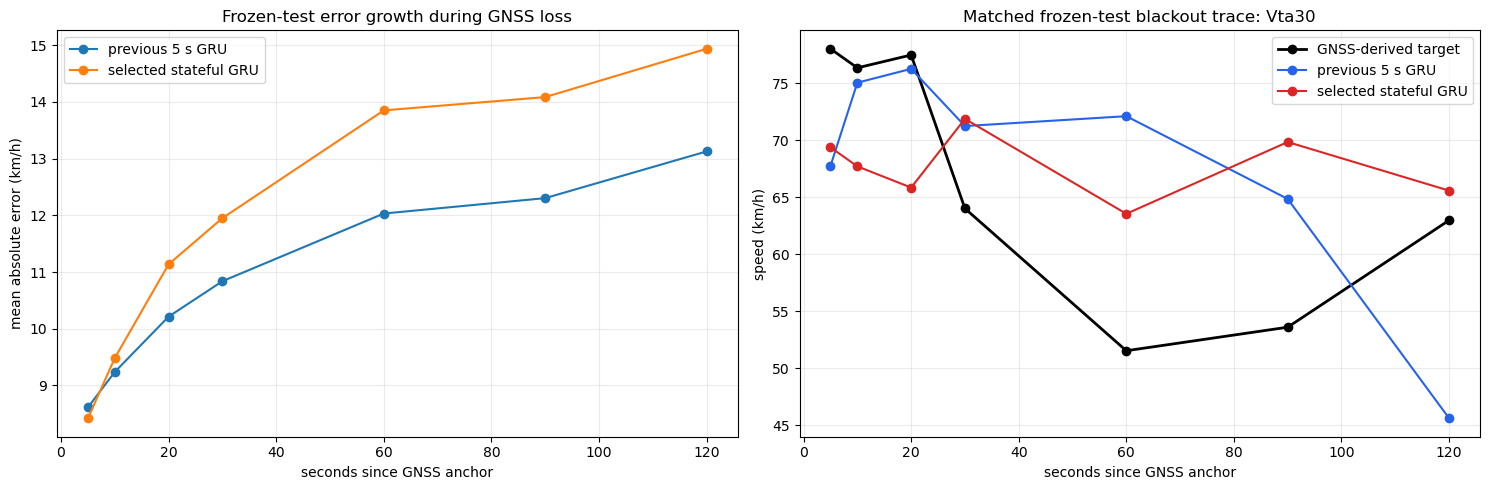

In [50]:
error_by_horizon = pd.concat(
    [
        test_comparison.assign(
            model="previous 5 s GRU",
            absolute_error_kmh=lambda rows: 3.6 * np.abs(
                rows.actual_speed_mps - rows.windowed_gru_prediction_mps
            ),
        )[["journey_id", "anchor_timestamp_ns", "horizon_s", "model", "absolute_error_kmh"]],
        test_comparison.assign(
            model="selected stateful GRU",
            absolute_error_kmh=lambda rows: 3.6 * np.abs(
                rows.actual_speed_mps - rows.stateful_gru_prediction_mps
            ),
        )[["journey_id", "anchor_timestamp_ns", "horizon_s", "model", "absolute_error_kmh"]],
    ],
    ignore_index=True,
)

horizon_summary = (
    error_by_horizon.groupby(["model", "horizon_s"], as_index=False)
    .absolute_error_kmh.mean()
)

anchor_error = (
    error_by_horizon[
        error_by_horizon.model == "selected stateful GRU"
    ]
    .groupby(["journey_id", "anchor_timestamp_ns"], as_index=False)
    .absolute_error_kmh.mean()
    .sort_values("absolute_error_kmh")
)

chosen_anchor = anchor_error.iloc[len(anchor_error) // 2]
trace = test_comparison[
    (test_comparison.journey_id == chosen_anchor.journey_id)
    & (test_comparison.anchor_timestamp_ns == chosen_anchor.anchor_timestamp_ns)
].sort_values("horizon_s")

figure, axes = plt.subplots(1, 2, figsize=(15, 5))

for model, rows in horizon_summary.groupby("model"):
    axes[0].plot(
        rows.horizon_s,
        rows.absolute_error_kmh,
        marker="o",
        label=model,
    )

axes[0].set(
    xlabel="seconds since GNSS anchor",
    ylabel="mean absolute error (km/h)",
    title="Frozen-test error growth during GNSS loss",
)
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(
    trace.horizon_s,
    trace.actual_speed_mps * 3.6,
    color="black",
    marker="o",
    linewidth=2,
    label="GNSS-derived target",
)
axes[1].plot(
    trace.horizon_s,
    trace.windowed_gru_prediction_mps * 3.6,
    color="#2563eb",
    marker="o",
    label="previous 5 s GRU",
)
axes[1].plot(
    trace.horizon_s,
    trace.stateful_gru_prediction_mps * 3.6,
    color="#dc2626",
    marker="o",
    label="selected stateful GRU",
)

axes[1].set(
    xlabel="seconds since GNSS anchor",
    ylabel="speed (km/h)",
    title=f"Matched frozen-test blackout trace: {chosen_anchor.journey_id}",
)
axes[1].grid(alpha=0.25)
axes[1].legend()

figure.tight_layout()
figure.savefig(
    STATEFUL_ARTIFACT_DIR / "frozen_test_stateful_vs_windowed_gru.png",
    dpi=160,
)
display(figure)
plt.close(figure)

In [51]:
frozen_test_metrics.to_csv(
    STATEFUL_ARTIFACT_DIR / "frozen_test_stateful_vs_windowed_metrics.csv",
    index=False,
)

test_comparison.to_csv(
    STATEFUL_ARTIFACT_DIR / "frozen_test_stateful_vs_windowed_predictions.csv",
    index=False,
)

## Production-preprocessor GRU retraining

The earlier selected GRU was trained from an experiment-local cleaner. This section rebuilds examples by replaying raw phone callbacks through the actual deterministic preprocessor, resampler, window builder, GNSS anchor, and acceleration integrator used by the deployed pipeline. CAN remains an offline label only.

It intentionally uses grouped cross-validation only. Previously exposed journeys, including the raw replay diagnostic `Vta6`, are excluded. The output OOF table is also the only valid input for a new deterministic uncertainty profile.

In [14]:
from copy import deepcopy
from dataclasses import asdict
from hashlib import sha256
import json
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | training device: {DEVICE}')

def _find_idr_repo_root(start):
    for candidate in (start, *start.parents):
        if (candidate / 'src' / 'idr_backend').is_dir():
            return candidate
    raise RuntimeError('Open this notebook inside the dead reckoning repository.')

REPO_ROOT = _find_idr_repo_root(Path.cwd().resolve())
for local_path in (REPO_ROOT / 'src', REPO_ROOT / 'notebooks'):
    if str(local_path) not in sys.path:
        sys.path.insert(0, str(local_path))
RAW_DATA_DIR = REPO_ROOT / 'SIH-2-main' / 'SIH-2-main' / 'IOVNBD-Speed-Prediction' / 'data' / 'raw'
assert RAW_DATA_DIR.is_dir(), f'Missing data: {RAW_DATA_DIR}'

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

from idr_backend.adapters.anchor_delta_gru import (
    ANCHOR_DELTA_GRU_CONTEXT_FEATURE_NAMES, AnchorDeltaGruPredictor,
)
from idr_backend.adapters.velocity_predictor import VelocityInferenceContext
from idr_backend.evaluation.production_velocity import (
    ProductionVelocityDatasetConfig, build_production_velocity_dataset,
)
from idr_backend.evaluation.replay import load_raw_replay_journey
from idr_backend.sensors.windowing import VELOCITY_MODEL_FEATURE_NAMES
from velocity_experiment import GruRegressor, regression_metrics

PRODUCTION_ARTIFACT_DIR = REPO_ROOT / 'artifacts' / 'production_preprocessor_anchor_delta_gru'
PRODUCTION_UQ_DIR = PRODUCTION_ARTIFACT_DIR / 'uncertainty'
PRODUCTION_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
PRODUCTION_UQ_DIR.mkdir(parents=True, exist_ok=True)

# These drives have already influenced an earlier velocity experiment or the
# raw-replay diagnosis. They are deliberately not reused as a clean score.
EXPOSED_JOURNEYS = {'S3a', 'S3c', 'Vfa01', 'Vta30', 'Vta6'}
all_journey_ids = sorted(
    path.stem[2:] for path in RAW_DATA_DIR.glob('S-*.csv')
    if (RAW_DATA_DIR / f'V-{path.stem[2:]}.csv').is_file()
)
production_training_ids = [
    journey_id for journey_id in all_journey_ids
    if journey_id not in EXPOSED_JOURNEYS
]
print(f'Production-training journeys: {len(production_training_ids)}')
print('Excluded exposed journeys:', sorted(EXPOSED_JOURNEYS))

PyTorch 2.7.1+cu118 | training device: cuda
Production-training journeys: 35
Excluded exposed journeys: ['S3a', 'S3c', 'Vfa01', 'Vta30', 'Vta6']


In [16]:
# Five-minute anchor spacing makes the exact raw callback replay practical.
# It changes offline example density only; each saved window still comes
# from the production preprocessor and a real GNSS-loss interval.
PRODUCTION_DATASET_CONFIG = ProductionVelocityDatasetConfig(
    warmup_s=30.0, anchor_stride_s=300.0,
    horizons_s=(5.0, 10.0, 20.0, 30.0, 60.0, 90.0, 120.0),
)
REBUILD_PRODUCTION_DATASET = False
production_cache = PRODUCTION_ARTIFACT_DIR / 'production_velocity_dataset.joblib'
production_cache_key = {
    'schema_version': 1, 'dataset_builder_revision': 1,
    'config': asdict(PRODUCTION_DATASET_CONFIG),
    'journey_ids': production_training_ids,
}
cached = joblib.load(production_cache) if production_cache.exists() and not REBUILD_PRODUCTION_DATASET else {}
if cached.get('cache_key') == production_cache_key:
    production_dataset = cached['dataset']
    production_audit = pd.DataFrame(cached['audit'])
    print(f'Loaded {len(production_dataset.target_delta_mps):,} production-compatible examples.')
else:
    raw_journeys = [load_raw_replay_journey(RAW_DATA_DIR, journey_id) for journey_id in production_training_ids]
    production_dataset, audit_rows = build_production_velocity_dataset(
        raw_journeys, config=PRODUCTION_DATASET_CONFIG
    )
    production_audit = pd.DataFrame([asdict(row) for row in audit_rows])
    joblib.dump(
        {'cache_key': production_cache_key, 'dataset': production_dataset, 'audit': production_audit.to_dict('records')},
        production_cache,
    )
display(production_audit.sort_values(['emitted_examples', 'journey_id']))
assert len(np.unique(production_dataset.journey_ids)) >= 5, 'Need five usable whole journeys for GroupKFold.'
assert set(production_dataset.journey_ids).isdisjoint(EXPOSED_JOURNEYS)
print('Window shape:', production_dataset.sequence_windows.shape)

Loaded 1,050 production-compatible examples.


,journey_id,attempted_anchors,emitted_examples,accepted_preprocessing_samples,calibration_warming_up_samples,calibration_untrusted_samples,quality_rejected_samples
7,Vta11,0,0,0,0,0,0
8,Vta12,0,0,0,0,0,0
9,Vta13,0,0,0,0,0,0
11,Vta15,0,0,0,0,0,0
14,Vta19,0,0,0,0,0,0
16,Vta1b,0,0,0,0,0,0
18,Vta20,1,0,0,1501,0,0
21,Vta23,0,0,0,0,0,0
22,Vta24,0,0,0,0,0,0
23,Vta25,0,0,0,0,0,0


Window shape: (1050, 50, 6)


In [8]:
# This small search changes only deployable GRU capacity/direction. The full
# five-second window is already in the past at prediction time, so either
# direction is causal; the exported ONNX graph preserves the winner exactly.
PRODUCTION_GRU_CANDIDATES = [
    {'hidden_size': 32, 'num_layers': 1, 'bidirectional': False, 'dropout': 0.1, 'learning_rate': 1e-3, 'weight_decay': 3e-4},
    {'hidden_size': 64, 'num_layers': 1, 'bidirectional': False, 'dropout': 0.1, 'learning_rate': 1e-3, 'weight_decay': 3e-4},
    {'hidden_size': 32, 'num_layers': 1, 'bidirectional': True,  'dropout': 0.1, 'learning_rate': 1e-3, 'weight_decay': 3e-4},
    {'hidden_size': 64, 'num_layers': 1, 'bidirectional': True,  'dropout': 0.1, 'learning_rate': 3e-4, 'weight_decay': 3e-4},
]
MAX_EPOCHS, PATIENCE, BATCH_SIZE = 100, 15, 256

def seed_production_run(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def fit_production_scalers(train_index):
    sequence_scaler = StandardScaler().fit(
        production_dataset.sequence_windows[train_index].reshape(-1, 6)
    )
    context_scaler = StandardScaler().fit(
        production_dataset.context_features[train_index]
    )
    return sequence_scaler, context_scaler

def scale_production_inputs(sequence_scaler, context_scaler, index):
    sequence = production_dataset.sequence_windows[index]
    sequence = sequence_scaler.transform(sequence.reshape(-1, 6)).reshape(sequence.shape)
    context = context_scaler.transform(production_dataset.context_features[index])
    return sequence.astype(np.float32), context.astype(np.float32)

def build_production_gru(parameters):
    return GruRegressor(
        n_channels=6, context_dim=5,
        hidden_size=int(parameters['hidden_size']),
        num_layers=int(parameters['num_layers']),
        bidirectional=bool(parameters['bidirectional']),
        dropout=float(parameters['dropout']),
    ).to(DEVICE)

def train_production_fold(parameters, train_index, validation_index, seed):
    seed_production_run(seed)
    sequence_scaler, context_scaler = fit_production_scalers(train_index)
    train_sequence, train_context = scale_production_inputs(sequence_scaler, context_scaler, train_index)
    validation_sequence, validation_context = scale_production_inputs(sequence_scaler, context_scaler, validation_index)
    train_loader = DataLoader(
        TensorDataset(
            torch.from_numpy(train_sequence), torch.from_numpy(train_context),
            torch.from_numpy(production_dataset.target_delta_mps[train_index]),
        ), batch_size=BATCH_SIZE, shuffle=True,
    )
    model = build_production_gru(parameters)
    optimizer = torch.optim.AdamW(model.parameters(), lr=float(parameters['learning_rate']), weight_decay=float(parameters['weight_decay']))
    best_state, best_prediction, best_score, best_epoch = None, None, float('inf'), 0
    stale_epochs = 0
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        for sequence, context, target_delta in train_loader:
            optimizer.zero_grad(set_to_none=True)
            prediction = model(sequence.to(DEVICE), context.to(DEVICE))
            loss = torch.nn.functional.smooth_l1_loss(prediction, target_delta.to(DEVICE))
            loss.backward()
            optimizer.step()
        model.eval()
        with torch.inference_mode():
            predicted_delta = model(
                torch.from_numpy(validation_sequence).to(DEVICE),
                torch.from_numpy(validation_context).to(DEVICE),
            ).cpu().numpy()
        predicted_speed = np.maximum(0.0, production_dataset.anchor_speed_mps[validation_index] + predicted_delta)
        score = regression_metrics(
            production_dataset.target_speed_mps[validation_index], predicted_speed,
            production_dataset.journey_ids[validation_index],
        )['macro_journey_mae_mps']
        if score < best_score:
            best_state, best_prediction, best_score, best_epoch = deepcopy(model.state_dict()), predicted_speed.copy(), score, epoch
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= PATIENCE:
                break
    return best_prediction, float(best_score), int(best_epoch)

group_splitter = GroupKFold(n_splits=5)
production_folds = list(group_splitter.split(
    production_dataset.sequence_windows, production_dataset.target_delta_mps, production_dataset.journey_ids
))
for train_index, validation_index in production_folds:
    assert set(production_dataset.journey_ids[train_index]).isdisjoint(production_dataset.journey_ids[validation_index])
print('Five whole-journey folds are ready.')

Five whole-journey folds are ready.


In [10]:
# This is the training cell. It preserves completed candidates in the two
# variables below, so an interrupt never erases earlier candidate results.
production_candidate_rows = []
production_candidate_oof = {}
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
for candidate_id, parameters in enumerate(PRODUCTION_GRU_CANDIDATES, start=1):
    oof_prediction = np.full(len(production_dataset.target_delta_mps), np.nan, dtype=np.float32)
    fold_scores, fold_epochs = [], []
    for fold_id, (train_index, validation_index) in enumerate(production_folds, start=1):
        prediction, score, best_epoch = train_production_fold(
            parameters, train_index, validation_index, seed=20260905 + candidate_id * 100 + fold_id
        )
        oof_prediction[validation_index] = prediction
        fold_scores.append(score)
        fold_epochs.append(best_epoch)
        print(f'candidate {candidate_id}/{len(PRODUCTION_GRU_CANDIDATES)}, fold {fold_id}/5: {score * 3.6:.2f} km/h at epoch {best_epoch}', flush=True)
    assert np.isfinite(oof_prediction).all()
    production_candidate_oof[candidate_id] = oof_prediction
    production_candidate_rows.append({
        'candidate_id': candidate_id, 'parameters': json.dumps(parameters, sort_keys=True),
        'cv_macro_journey_mae_mps': float(np.mean(fold_scores)),
        'cv_macro_journey_mae_kmh': float(np.mean(fold_scores) * 3.6),
        'cv_macro_journey_mae_std_mps': float(np.std(fold_scores)),
        'fold_best_epochs': fold_epochs,
    })
production_selection = pd.DataFrame(production_candidate_rows).sort_values('cv_macro_journey_mae_mps').reset_index(drop=True)
display(production_selection)
production_selection.to_csv(PRODUCTION_ARTIFACT_DIR / 'grouped_cv_selection.csv', index=False)

candidate 1/4, fold 1/5: 10.57 km/h at epoch 85
candidate 1/4, fold 2/5: 13.43 km/h at epoch 60
candidate 1/4, fold 3/5: 15.42 km/h at epoch 19
candidate 1/4, fold 4/5: 17.60 km/h at epoch 1
candidate 1/4, fold 5/5: 13.09 km/h at epoch 27
candidate 2/4, fold 1/5: 12.35 km/h at epoch 45
candidate 2/4, fold 2/5: 12.40 km/h at epoch 94
candidate 2/4, fold 3/5: 15.44 km/h at epoch 6
candidate 2/4, fold 4/5: 17.58 km/h at epoch 2
candidate 2/4, fold 5/5: 13.24 km/h at epoch 18
candidate 3/4, fold 1/5: 10.02 km/h at epoch 78
candidate 3/4, fold 2/5: 14.54 km/h at epoch 9
candidate 3/4, fold 3/5: 15.45 km/h at epoch 7
candidate 3/4, fold 4/5: 14.67 km/h at epoch 77
candidate 3/4, fold 5/5: 12.79 km/h at epoch 23
candidate 4/4, fold 1/5: 13.41 km/h at epoch 98
candidate 4/4, fold 2/5: 14.52 km/h at epoch 38
candidate 4/4, fold 3/5: 15.47 km/h at epoch 2
candidate 4/4, fold 4/5: 17.52 km/h at epoch 25
candidate 4/4, fold 5/5: 13.11 km/h at epoch 42


,candidate_id,parameters,cv_macro_journey_mae_mps,cv_macro_journey_mae_kmh,cv_macro_journey_mae_std_mps,fold_best_epochs
0,3,"{""bidirectional"": true, ""dropout"": 0.1, ""hidde...",3.748285,13.493827,0.539794,"[78, 9, 7, 77, 23]"
1,1,"{""bidirectional"": false, ""dropout"": 0.1, ""hidd...",3.895559,14.024014,0.656043,"[85, 60, 19, 1, 27]"
2,2,"{""bidirectional"": false, ""dropout"": 0.1, ""hidd...",3.945619,14.204227,0.562874,"[45, 94, 6, 2, 18]"
3,4,"{""bidirectional"": true, ""dropout"": 0.1, ""hidde...",4.112534,14.805122,0.443196,"[98, 38, 2, 25, 42]"


In [11]:
# Refit only after the grouped-CV winner is selected. Its OOF predictions
# remain separate and are used below for covariance calibration.
winner = production_selection.iloc[0]
winner_id = int(winner.candidate_id)
winner_parameters = PRODUCTION_GRU_CANDIDATES[winner_id - 1]
winner_oof_speed = production_candidate_oof[winner_id]
refit_epochs = max(1, int(np.median(winner.fold_best_epochs)))
all_index = np.arange(len(production_dataset.target_delta_mps))
sequence_scaler, context_scaler = fit_production_scalers(all_index)
all_sequence, all_context = scale_production_inputs(sequence_scaler, context_scaler, all_index)
final_model = build_production_gru(winner_parameters)
final_optimizer = torch.optim.AdamW(final_model.parameters(), lr=float(winner_parameters['learning_rate']), weight_decay=float(winner_parameters['weight_decay']))
final_loader = DataLoader(
    TensorDataset(torch.from_numpy(all_sequence), torch.from_numpy(all_context), torch.from_numpy(production_dataset.target_delta_mps)),
    batch_size=BATCH_SIZE, shuffle=True,
)
for epoch in range(1, refit_epochs + 1):
    final_model.train()
    for sequence, context, target_delta in final_loader:
        final_optimizer.zero_grad(set_to_none=True)
        loss = torch.nn.functional.smooth_l1_loss(final_model(sequence.to(DEVICE), context.to(DEVICE)), target_delta.to(DEVICE))
        loss.backward(); final_optimizer.step()
    print(f'Final refit {epoch:03d}/{refit_epochs}', flush=True)

# OOF rows are generated only by models that did not train on their journey.
oof_residual_mps = production_dataset.target_speed_mps - winner_oof_speed
production_oof = pd.DataFrame({
    'journey_id': production_dataset.journey_ids,
    'anchor_timestamp_ns': production_dataset.anchor_timestamps_ns,
    'end_timestamp_ns': production_dataset.end_timestamps_ns,
    'horizon_s': production_dataset.horizons_s,
    'anchor_speed_mps': production_dataset.anchor_speed_mps,
    'actual_speed_mps': production_dataset.target_speed_mps,
    'prediction_speed_mps': winner_oof_speed,
    'residual_mps': oof_residual_mps,
})
for column_index, column_name in enumerate([
    'linear_acceleration_rms_mps2', 'linear_acceleration_magnitude_std_mps2',
    'angular_velocity_rms_radps', 'minimum_calibration_confidence',
    'final_quality_score', 'window_duration_s', 'seconds_since_anchor',
]):
    production_oof[column_name] = production_dataset.uncertainty_base_features[:, column_index]
production_oof['predicted_speed_mps'] = winner_oof_speed
production_oof_path = PRODUCTION_ARTIFACT_DIR / 'production_anchor_delta_gru_oof.csv'
production_oof.to_csv(production_oof_path, index=False)
display(pd.DataFrame([regression_metrics(
    production_dataset.target_speed_mps, winner_oof_speed, production_dataset.journey_ids
)]))

# Export the refit model with the exact contract checked by AnchorDeltaGruPredictor.
onnx_path = PRODUCTION_ARTIFACT_DIR / 'anchor_delta_gru.onnx'
metadata_path = PRODUCTION_ARTIFACT_DIR / 'anchor_delta_gru.metadata.json'
final_model = final_model.to('cpu').eval()
with torch.inference_mode():
    torch.onnx.export(
        final_model,
        (torch.zeros((1, production_dataset.sequence_windows.shape[1], 6), dtype=torch.float32), torch.zeros((1, 5), dtype=torch.float32)),
        str(onnx_path), input_names=['imu_window', 'context'],
        output_names=['speed_delta_mps'], opset_version=17,
    )
metadata = {
    'schema_version': 1, 'model_family': 'anchor_delta_gru',
    'model_id': 'anchor_delta_gru_production_preprocessor_v1',
    'input': {
        'sequence_feature_names': list(VELOCITY_MODEL_FEATURE_NAMES),
        'context_feature_names': list(ANCHOR_DELTA_GRU_CONTEXT_FEATURE_NAMES),
        'window_size': int(production_dataset.sequence_windows.shape[1]),
        'sample_period_ns': 100_000_000,
    },
    'target': {'kind': 'speed_delta_from_anchor', 'unit': 'm/s', 'postprocess': 'max(0, anchor_speed_mps + model_output)'},
    'normalization': {
        'sequence': {'mean': sequence_scaler.mean_.tolist(), 'scale': sequence_scaler.scale_.tolist()},
        'context': {'mean': context_scaler.mean_.tolist(), 'scale': context_scaler.scale_.tolist()},
    },
    'training': {
        'preprocessor': 'DeterministicImuPreprocessor/default_preprocessor_config',
        'dataset_config': asdict(PRODUCTION_DATASET_CONFIG),
        'split': 'five-fold grouped CV by journey; exposed journeys excluded',
        'winner_parameters': winner_parameters, 'refit_epochs': refit_epochs,
    },
}
metadata_path.write_text(json.dumps(metadata, indent=2), encoding='utf-8')

# Fit an interpretable, monotone uncertainty schedule only from the winner's
# OOF residuals. This is calibrated covariance, not a second speed model.
horizons = tuple(float(value) for value in PRODUCTION_DATASET_CONFIG.horizons_s)
base_std = []
for horizon in horizons:
    absolute_residuals = np.abs(production_oof.loc[production_oof.horizon_s == horizon, 'residual_mps'])
    base_std.append(float(np.quantile(absolute_residuals, 0.6827)))
base_std = np.maximum.accumulate(np.maximum(base_std, 0.25)).tolist()
def file_hash(path):
    return sha256(path.read_bytes()).hexdigest()
profile = {
    'schema_version': 1, 'profile_kind': 'deterministic_velocity_uncertainty',
    'velocity_model_id': metadata['model_id'],
    'velocity_onnx_sha256': file_hash(onnx_path),
    'velocity_metadata_sha256': file_hash(metadata_path),
    'horizon_seconds': list(horizons),
    'base_standard_deviation_mps': base_std,
    'variance_ceiling_m2ps2': float(max(25.0, (3.0 * max(base_std)) ** 2)),
    'risk_inflation': {
        'reference_acceleration_std_mps2': float(max(0.1, production_oof.linear_acceleration_magnitude_std_mps2.quantile(0.75))),
        'reference_angular_velocity_rms_radps': float(max(0.1, production_oof.angular_velocity_rms_radps.quantile(0.75))),
        'reference_minimum_calibration_confidence': float(max(0.01, production_oof.minimum_calibration_confidence.median())),
        'reference_final_quality_score': float(max(0.01, production_oof.final_quality_score.median())),
        'roughness_std_multiplier': 0.25, 'turn_std_multiplier': 0.25,
        'calibration_std_multiplier': 0.50, 'quality_std_multiplier': 0.25,
    },
    'calibration_data': 'grouped out-of-fold residuals from production-preprocessor replay only',
}
profile_path = PRODUCTION_UQ_DIR / 'production_anchor_delta_gru_deterministic_uncertainty.json'
profile_path.write_text(json.dumps(profile, indent=2), encoding='utf-8')
print('Saved:', onnx_path, metadata_path, production_oof_path, profile_path, sep='\n')

Final refit 001/23
Final refit 002/23
Final refit 003/23
Final refit 004/23
Final refit 005/23
Final refit 006/23
Final refit 007/23
Final refit 008/23
Final refit 009/23
Final refit 010/23
Final refit 011/23
Final refit 012/23
Final refit 013/23
Final refit 014/23
Final refit 015/23
Final refit 016/23
Final refit 017/23
Final refit 018/23
Final refit 019/23
Final refit 020/23
Final refit 021/23
Final refit 022/23
Final refit 023/23


,mae_mps,mae_kmh,rmse_mps,rmse_kmh,macro_journey_mae_mps,macro_journey_mae_kmh,r2
0,4.483334,16.140001,6.080938,21.891375,3.823757,13.765526,0.452082


e:\ANACONDA\Lib\site-packages\torch\onnx\symbolic_opset9.py:4244: UserWarning: Exporting a model to ONNX with a batch_size other than 1, with a variable length with GRU can cause an error when running the ONNX model with a different batch size. Make sure to save the model with a batch size of 1, or define the initial states (h0/c0) as inputs of the model. 
  warnings.warn(


Saved:
E:\dead reckoning\artifacts\production_preprocessor_anchor_delta_gru\anchor_delta_gru.onnx
E:\dead reckoning\artifacts\production_preprocessor_anchor_delta_gru\anchor_delta_gru.metadata.json
E:\dead reckoning\artifacts\production_preprocessor_anchor_delta_gru\production_anchor_delta_gru_oof.csv
E:\dead reckoning\artifacts\production_preprocessor_anchor_delta_gru\uncertainty\production_anchor_delta_gru_deterministic_uncertainty.json


In [12]:
# Artifact smoke check: raw PyTorch and ONNX adapter must agree on a real
# production-preprocessed window. The strict runtime loader also verifies
# the deterministic uncertainty profile's two hashes.
from idr_backend.pipeline.selected_velocity import (
    SelectedVelocityRuntimeArtifacts, load_selected_velocity_runtime_components,
)

runtime_components = load_selected_velocity_runtime_components(
    SelectedVelocityRuntimeArtifacts(
        velocity_artifact_directory=PRODUCTION_ARTIFACT_DIR,
        uncertainty_artifact_directory=PRODUCTION_UQ_DIR,
        uncertainty_profile_filename=profile_path.name,
    )
)
smoke_index = 0
smoke_context = VelocityInferenceContext(
    source_id='phone-primary',
    anchor_timestamp_ns=int(production_dataset.anchor_timestamps_ns[smoke_index]),
    anchor_speed_mps=float(production_dataset.anchor_speed_mps[smoke_index]),
    integrated_speed_mps=float(production_dataset.context_features[smoke_index, 1]),
    seconds_since_anchor=float(production_dataset.context_features[smoke_index, 2]),
    mean_calibration_confidence=float(production_dataset.context_features[smoke_index, 3]),
    minimum_calibration_confidence=float(production_dataset.context_features[smoke_index, 4]),
)
onnx_predictor = AnchorDeltaGruPredictor.from_artifact_directory(PRODUCTION_ARTIFACT_DIR)
onnx_speed = onnx_predictor.predict_speed_mps(
    tuple(tuple(float(value) for value in row) for row in production_dataset.sequence_windows[smoke_index]),
    smoke_context,
)
with torch.inference_mode():
    torch_delta = final_model(
        torch.from_numpy(sequence_scaler.transform(production_dataset.sequence_windows[smoke_index]).astype(np.float32))[None],
        torch.from_numpy(context_scaler.transform(production_dataset.context_features[smoke_index:smoke_index + 1]).astype(np.float32)),
    ).item()
torch_speed = max(0.0, smoke_context.anchor_speed_mps + torch_delta)
assert np.isclose(onnx_speed, torch_speed, rtol=1e-4, atol=1e-4)
assert runtime_components.velocity_predictor.model_id == metadata['model_id']
print(f'ONNX/runtime smoke passed: {onnx_speed:.4f} m/s; model={metadata["model_id"]}')

ONNX/runtime smoke passed: 1.7282 m/s; model=anchor_delta_gru_production_preprocessor_v1


# Final production-preprocessor velocity investigation (v2)

This section leaves every earlier experiment and selected artifact unchanged. It rebuilds both windowed and streaming examples from one exact raw replay, uses whole-journey folds only, and promotes nothing automatically. The old selected GRU remains the runtime default unless a new candidate clears every documented gate. Training may reweight sparse real cases and add only small zero-mean sensor jitter (at most 5% of a robust channel scale); it intentionally does not use magnitude scaling or time warping because either could break the physical acceleration-time-speed relationship.

In [38]:
# Run the existing imports/cells through production cell 55 first, then this section.
from dataclasses import asdict
from pathlib import Path
import json
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import importlib

# This notebook has older experiments above this section.  Reload the two
# edited modules so a long-lived kernel cannot retain their earlier API.
import idr_backend.evaluation.production_velocity as _production_velocity_module
importlib.invalidate_caches()
importlib.reload(_production_velocity_module)
import final_velocity_experiment as _final_velocity_experiment_module
importlib.reload(_final_velocity_experiment_module)

from idr_backend.evaluation.production_velocity import (
    ProductionVelocityDatasetConfig, build_production_velocity_experiment_dataset,
    fold_balanced_sample_weights, production_velocity_eda_frame,
)
from idr_backend.evaluation.replay import load_raw_replay_journey
from final_velocity_experiment import (
    CANONICAL_HORIZONS_S, FINAL_SEARCH_SEED, SearchLimits,
    export_stateful_onnx, export_windowed_onnx, fit_stateful_fold,
    fit_windowed_fold, fold_assignment_frame, grouped_folds,
macro_journey_mae, refit_stateful_winner, refit_windowed_winner,
    run_successive_halving, sequence_grouped_folds, stateful_candidates,
    windowed_candidates, write_deterministic_uncertainty_profile,
    write_stateful_deterministic_uncertainty_profile,
)

FINAL_V2_DIR = REPO_ROOT / 'artifacts' / 'final_velocity_search_v2'
FINAL_V2_DIR.mkdir(parents=True, exist_ok=True)
FINAL_DATASET_CONFIG = ProductionVelocityDatasetConfig(
    warmup_s=30.0, anchor_stride_s=60.0,
    horizons_s=tuple(float(value) for value in range(5, 125, 5)),
    maximum_anchor_age_s=120.0, horizon_match_tolerance_s=0.11,
)
FINAL_EXPOSED_JOURNEYS = {'S3a', 'S3c', 'Vfa01', 'Vta30', 'Vta6'}
FINAL_TRAINING_IDS = [journey_id for journey_id in all_journey_ids if journey_id not in FINAL_EXPOSED_JOURNEYS]
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Final v2 training device: {DEVICE}; development journeys: {len(FINAL_TRAINING_IDS)}')

Final v2 training device: cuda; development journeys: 35


In [39]:
# This cache contains both model views from ONE raw replay per anchor.
# Rebuilding is deliberately explicit: it may take substantial CPU time.
REBUILD_FINAL_V2_DATASET = False
FINAL_V2_CACHE = FINAL_V2_DIR / 'production_windowed_and_stateful_dataset.joblib'
FINAL_V2_CACHE_KEY = {
    'schema_version': 2, 'builder': 'shared_windowed_stateful_raw_replay',
    'config': asdict(FINAL_DATASET_CONFIG), 'journey_ids': FINAL_TRAINING_IDS,
    'stateful_label_period_s': 1.0,
}
cached = joblib.load(FINAL_V2_CACHE) if FINAL_V2_CACHE.exists() and not REBUILD_FINAL_V2_DATASET else {}
if cached.get('cache_key') == FINAL_V2_CACHE_KEY:
    final_experiment_data = cached['experiment_data']
    print('Loaded final v2 replay cache.')
else:
    final_raw_journeys = [load_raw_replay_journey(RAW_DATA_DIR, journey_id) for journey_id in FINAL_TRAINING_IDS]
    final_experiment_data = build_production_velocity_experiment_dataset(
        final_raw_journeys, config=FINAL_DATASET_CONFIG, stateful_label_period_s=1.0
    )
    joblib.dump({'cache_key': FINAL_V2_CACHE_KEY, 'experiment_data': final_experiment_data}, FINAL_V2_CACHE)

final_dataset = final_experiment_data.windowed
final_sequences = final_experiment_data.stateful_sequences
final_audit = pd.DataFrame([asdict(row) for row in final_experiment_data.audits])
assert len(np.unique(final_dataset.journey_ids)) >= 5
assert set(final_dataset.journey_ids).isdisjoint(FINAL_EXPOSED_JOURNEYS)
print(f'Windowed examples: {len(final_dataset.target_delta_mps):,}; stateful anchors: {len(final_sequences):,}; journeys: {len(np.unique(final_dataset.journey_ids))}')
display(final_audit.sort_values(['emitted_examples', 'journey_id']))

Loaded final v2 replay cache.
Windowed examples: 16,828; stateful anchors: 697; journeys: 21


,journey_id,attempted_anchors,emitted_examples,accepted_preprocessing_samples,calibration_warming_up_samples,calibration_untrusted_samples,quality_rejected_samples
7,Vta11,0,0,0,0,0,0
8,Vta12,0,0,0,0,0,0
9,Vta13,0,0,0,0,0,0
11,Vta15,0,0,0,0,0,0
14,Vta19,0,0,0,0,0,0
16,Vta1b,0,0,0,0,0,0
18,Vta20,3,0,0,4501,0,0
21,Vta23,0,0,0,0,0,0
22,Vta24,0,0,0,0,0,0
23,Vta25,0,0,0,0,0,0


,journey_id,anchor_timestamp_ns,end_timestamp_ns,horizon_s,anchor_speed_kmh,target_speed_kmh,speed_delta_kmh,absolute_speed_delta_kmh,forward_acceleration_rms_mps2,yaw_rate_rms_radps,minimum_calibration_confidence
count,16828,1.682800e+04,1.682800e+04,16828.000000,16828.000000,16828.000000,16828.000000,16828.000000,16828.000000,16828.000000,16828.000000
unique,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,S2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,3430,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2.980507e+12,3.042980e+12,62.473259,42.883709,41.068924,-1.814785,17.658541,1.550065,0.090073,0.647552
std,NaN,2.197948e+12,2.198246e+12,34.606121,28.058903,29.462439,23.968863,16.308174,1.227127,0.064710,0.063466
min,NaN,2.920000e+10,3.420000e+10,5.000000,0.000000,0.000000,-105.479996,0.000000,0.017162,0.001308,0.600000
25%,NaN,1.049517e+12,1.099554e+12,30.000000,23.291998,20.988725,-14.572000,5.131893,0.732054,0.044488,0.600000
50%,NaN,2.669417e+12,2.719208e+12,60.000000,37.727997,36.230000,-0.819000,12.697999,1.178299,0.079013,0.617690
75%,NaN,4.590006e+12,4.679974e+12,90.000000,58.211998,55.541825,11.139061,25.912985,1.997841,0.118147,0.676864


,examples
journey_id,
S2,3430
Vfa02,2615
Y1,2340
S1,1967
M,1918
S4,1512
Vta29,864
Vta1a,744
Vta16,408


absolute_speed_delta_kmh (0.0, 5.0]                                            \
horizon_s                     5.0   10.0  15.0  20.0  25.0  30.0  35.0  40.0    
target_speed_kmh                                                                
(0.0, 20.0]                      24    17    13    11    13    14    17     8   
(20.0, 40.0]                     71    64    53    60    55    57    52    58   
(40.0, 60.0]                     46    41    38    39    35    34    38    30   
(60.0, 80.0]                     19    11    13    10    12     9     9     8   
(80.0, inf]                      94    84    69    64    58    52    62    52   

absolute_speed_delta_kmh              ... (40.0, inf]                          \
horizon_s                45.0  50.0   ...       75.0  80.0  85.0  90.0  95.0    
target_speed_kmh                      ...                                       
(0.0, 20.0]                 13    16  ...          14    14    11     9    13   
(20.0, 40.0]                60    47  ...           9     7     4     6    10   
(40.0, 60.0]                30    32  ...          11    19    21    14    10   
(60.0, 80.0]                 7    12  ...          14     8    10     7     9   
(80.0, inf]                 51    53  ...           7     7     8     6     6   

absolute_speed_delta_kmh                                
horizon_s                100.0 105.0 110.0 115.0 120.0  
target_speed_kmh                                        
(0.0, 20.0]                  5    12    10    15    13  
(20.0, 40.0]                 8     4     8     4     4  
(40.0, 60.0]                15    10    14    13    15  
(60.0, 80.0]                12    19    17    18    17  
(80.0, inf]                  5     4     5     6     6  

[5 rows x 120 columns]

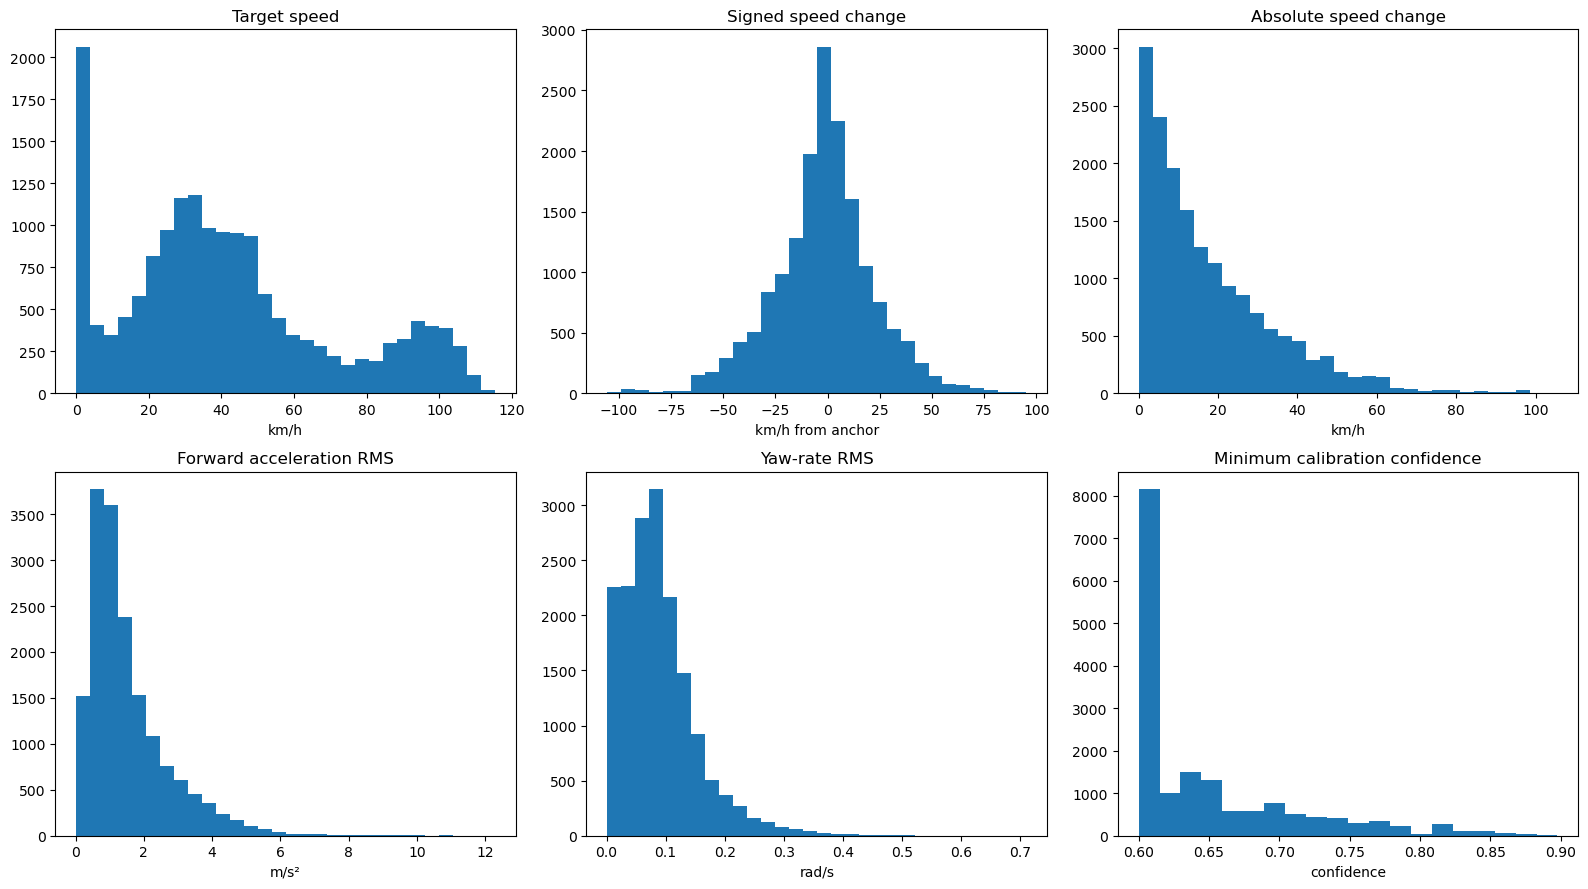

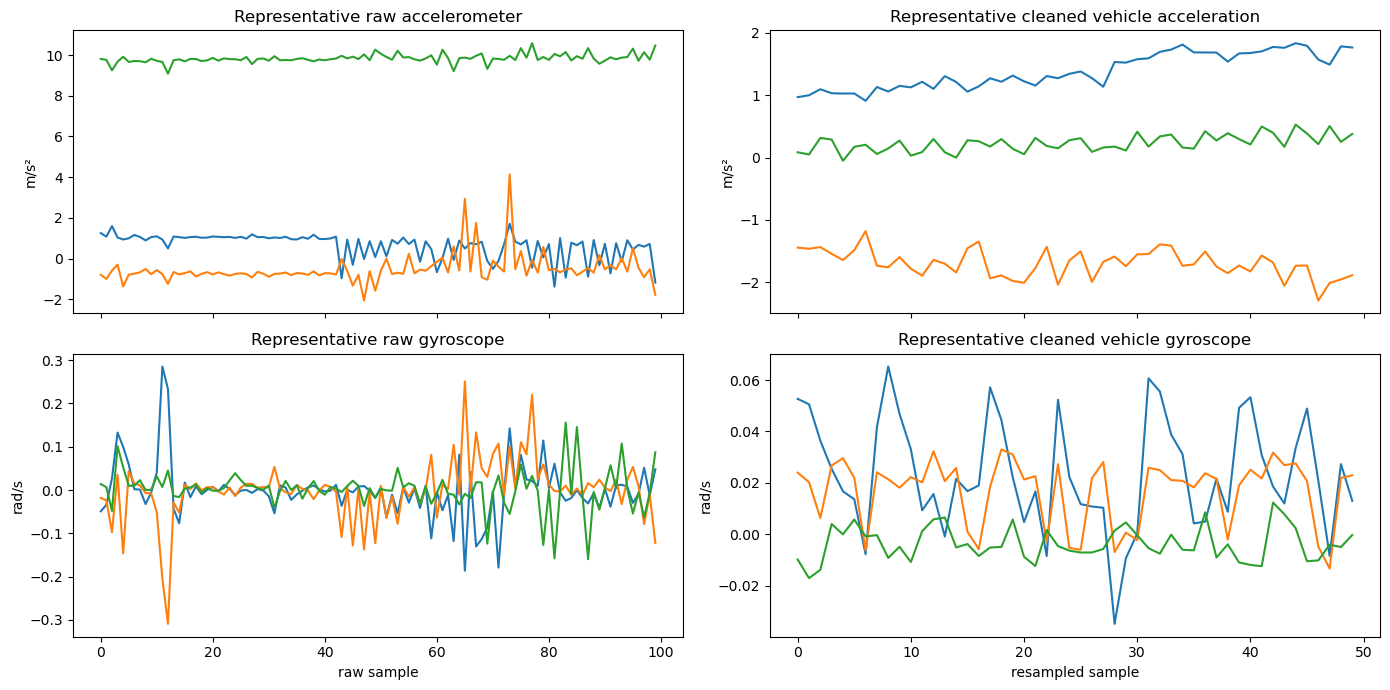

In [40]:
# EDA is development-only. Labels appear here, never in runtime features.
final_eda = production_velocity_eda_frame(final_dataset)
display(final_eda.describe(include='all'))
display(final_eda.groupby('journey_id').size().sort_values(ascending=False).rename('examples').to_frame())

figure, axes = plt.subplots(2, 3, figsize=(16, 9))
axes[0, 0].hist(final_eda.target_speed_kmh, bins=30); axes[0, 0].set(title='Target speed', xlabel='km/h')
axes[0, 1].hist(final_eda.speed_delta_kmh, bins=30); axes[0, 1].set(title='Signed speed change', xlabel='km/h from anchor')
axes[0, 2].hist(final_eda.absolute_speed_delta_kmh, bins=30); axes[0, 2].set(title='Absolute speed change', xlabel='km/h')
axes[1, 0].hist(final_eda.forward_acceleration_rms_mps2, bins=30); axes[1, 0].set(title='Forward acceleration RMS', xlabel='m/s²')
axes[1, 1].hist(final_eda.yaw_rate_rms_radps, bins=30); axes[1, 1].set(title='Yaw-rate RMS', xlabel='rad/s')
axes[1, 2].hist(final_eda.minimum_calibration_confidence, bins=20); axes[1, 2].set(title='Minimum calibration confidence', xlabel='confidence')
figure.tight_layout()

heatmap = pd.crosstab(
    pd.cut(final_eda.target_speed_kmh, [0, 20, 40, 60, 80, np.inf]),
    [pd.cut(final_eda.absolute_speed_delta_kmh, [0, 5, 10, 20, 40, np.inf]), final_eda.horizon_s],
)
display(heatmap)

# Representative raw and cleaned channels: the panels are intentionally labelled
# as separate examples because the dense cache does not retain their raw index.
eda_raw = load_raw_replay_journey(RAW_DATA_DIR, FINAL_TRAINING_IDS[0])
figure, axes = plt.subplots(2, 2, figsize=(14, 7), sharex='col')
axes[0, 0].plot(eda_raw.acceleration_sensor_mps2[:100]); axes[0, 0].set(title='Representative raw accelerometer', ylabel='m/s²')
axes[0, 1].plot(final_dataset.sequence_windows[0, :, :3]); axes[0, 1].set(title='Representative cleaned vehicle acceleration', ylabel='m/s²')
axes[1, 0].plot(eda_raw.angular_velocity_sensor_radps[:100]); axes[1, 0].set(title='Representative raw gyroscope', xlabel='raw sample', ylabel='rad/s')
axes[1, 1].plot(final_dataset.sequence_windows[0, :, 3:]); axes[1, 1].set(title='Representative cleaned vehicle gyroscope', xlabel='resampled sample', ylabel='rad/s')
figure.tight_layout()

In [41]:
final_folds = grouped_folds(final_dataset.journey_ids)
fold_assignments = fold_assignment_frame(final_dataset.journey_ids, final_folds)
fold_assignments.to_csv(FINAL_V2_DIR / 'journey_fold_assignments.csv', index=False)
final_stateful_folds = sequence_grouped_folds(final_sequences, final_folds, final_dataset)
for train_index, validation_index in final_folds:
    assert set(final_dataset.journey_ids[train_index]).isdisjoint(final_dataset.journey_ids[validation_index])
display(fold_assignments)

# Four short runs establish whether density/balancing/jitter help before the costly search.
# The sparse baseline comes from earlier cell 55 and is not a clean final score.
assert 'production_dataset' in globals(), 'Run the earlier production dataset cell 55 before this ablation.'
ABLATION_LIMITS = SearchLimits(maximum_epochs=50, patience=10, batch_size=128)
ablation_parameters = windowed_candidates()[0]
ablation_recipes = [
    ('original_sparse', production_dataset, False, 0.0),
    ('dense_unweighted', final_dataset, False, 0.0),
    ('dense_balanced', final_dataset, True, 0.0),
    ('dense_balanced_jitter', final_dataset, True, 0.05),
]
ablation_rows = []
for recipe, dataset_view, balanced, jitter in ablation_recipes:
    train_index, validation_index = grouped_folds(dataset_view.journey_ids)[0]
    outcome = fit_windowed_fold(
        dataset_view, train=train_index, validation=validation_index, parameters=ablation_parameters,
        limits=ABLATION_LIMITS, use_balanced_sampler=balanced, jitter_fraction=jitter,
        seed=FINAL_SEARCH_SEED, device=DEVICE,
        checkpoint_path=FINAL_V2_DIR / 'ablation' / f'{recipe}.pt', log_prefix=recipe,
    )
    ablation_rows.append({'recipe': recipe, 'macro_journey_mae_mps': outcome.macro_journey_mae_mps, 'macro_journey_mae_kmh': outcome.macro_journey_mae_mps * 3.6})
ablation = pd.DataFrame(ablation_rows).sort_values('macro_journey_mae_mps').reset_index(drop=True)
ablation.to_csv(FINAL_V2_DIR / 'ablation.csv', index=False)
display(ablation)
# The sparse replay is a diagnostic reference only: it has a different anchor
# density and endpoint distribution, so it cannot choose a dense training recipe.
# Prefer the simplest *dense* recipe within 0.2 km/h of the dense winner.
recipe_order = ['dense_unweighted', 'dense_balanced', 'dense_balanced_jitter']
dense_ablation = ablation.loc[ablation.recipe.isin(recipe_order)].copy()
best_dense_ablation = float(dense_ablation.macro_journey_mae_kmh.min())
SELECTED_RECIPE = next(recipe for recipe in recipe_order if float(dense_ablation.loc[dense_ablation.recipe == recipe, 'macro_journey_mae_kmh'].iloc[0]) <= best_dense_ablation + 0.2)
USE_BALANCED_SAMPLER = SELECTED_RECIPE != 'dense_unweighted'
JITTER_FRACTION = 0.05 if SELECTED_RECIPE == 'dense_balanced_jitter' else 0.0
print('Selected recipe:', SELECTED_RECIPE, '| balanced:', USE_BALANCED_SAMPLER, '| jitter:', JITTER_FRACTION)

,journey_id,validation_fold
0,M,5
1,S1,4
2,S2,1
3,S3b,2
4,S4,5
5,Vfa02,2
6,Vta10,3
7,Vta14,3
8,Vta16,2
9,Vta17,3


dense_unweighted epoch 018 | train loss 2.4503 | validation macro MAE 18.38 km/h
dense_balanced epoch 023 | train loss 1.5378 | validation macro MAE 19.47 km/h
dense_balanced_jitter epoch 013 | train loss 1.9797 | validation macro MAE 18.85 km/h


,recipe,macro_journey_mae_mps,macro_journey_mae_kmh
0,original_sparse,3.302984,11.890744
1,dense_unweighted,4.751887,17.106793
2,dense_balanced,5.139909,18.503672
3,dense_balanced_jitter,5.153564,18.552830


Selected recipe: dense_unweighted | balanced: False | jitter: 0.0


In [ ]:
# A fixed five-fold windowed baseline makes promotion measurable.  It is the
# earlier production-compatible five-second recipe, retrained fairly on the
# same dense raw-replay examples.  Search candidates must beat it by 0.5 km/h.
PRODUCTION_BASELINE_PARAMETERS = {
    'hidden_size': 32, 'num_layers': 1, 'bidirectional': True,
    'dropout': 0.1, 'learning_rate': 1e-3, 'weight_decay': 3e-4,
}
BASELINE_DIR = FINAL_V2_DIR / 'production_compatible_windowed_baseline'
BASELINE_RESULTS_PATH = BASELINE_DIR / 'folds.csv'
baseline_rows = pd.read_csv(BASELINE_RESULTS_PATH).to_dict('records') if BASELINE_RESULTS_PATH.exists() else []
baseline_done = {int(row['fold_id']) for row in baseline_rows}
for fold_id, (train_index, validation_index) in enumerate(final_folds, start=1):
    if fold_id in baseline_done:
        print(f'baseline fold {fold_id}/5: resumed')
        continue
    outcome = fit_windowed_fold(
        final_dataset, train=train_index, validation=validation_index,
        parameters=PRODUCTION_BASELINE_PARAMETERS,
        limits=SearchLimits(maximum_epochs=100, patience=15, batch_size=128),
        use_balanced_sampler=False, jitter_fraction=0.0,
        seed=FINAL_SEARCH_SEED + fold_id, device=DEVICE,
        checkpoint_path=BASELINE_DIR / 'checkpoints' / f'fold_{fold_id}.pt',
        log_prefix=f'production baseline fold {fold_id}/5',
    )
    prediction_path = BASELINE_DIR / 'predictions' / f'fold_{fold_id}.csv'
    prediction_path.parent.mkdir(parents=True, exist_ok=True)
    outcome.predictions.to_csv(prediction_path, index=False)
    baseline_rows.append({'fold_id': fold_id, 'macro_journey_mae_mps': outcome.macro_journey_mae_mps, 'best_epoch': outcome.best_epoch, 'elapsed_seconds': outcome.elapsed_seconds, 'cpu_inference_p95_ms': outcome.cpu_inference_p95_ms})
    pd.DataFrame(baseline_rows).to_csv(BASELINE_RESULTS_PATH, index=False)
production_baseline_folds = pd.DataFrame(baseline_rows).sort_values('fold_id')
production_baseline_oof = pd.concat([pd.read_csv(BASELINE_DIR / 'predictions' / f'fold_{fold_id}.csv') for fold_id in range(1, 6)], ignore_index=True)
display(production_baseline_folds)
# Interrupt-safe 20 → 6 → 2 searches. Re-running resumes completed folds.
def train_windowed_final(parameters, train, validation, limits, checkpoint_path, prefix):
    return fit_windowed_fold(
        final_dataset, train=train, validation=validation, parameters=parameters, limits=limits,
        use_balanced_sampler=USE_BALANCED_SAMPLER, jitter_fraction=JITTER_FRACTION,
        seed=FINAL_SEARCH_SEED + 10_000 * int(parameters['_candidate_id']) + int(parameters['_fold_id']),
        device=DEVICE, checkpoint_path=checkpoint_path, log_prefix=prefix,
    )

def train_stateful_final(parameters, train, validation, limits, checkpoint_path, prefix):
    return fit_stateful_fold(
        final_sequences, train=train, validation=validation, parameters=parameters, limits=limits,
        jitter_fraction=JITTER_FRACTION, seed=FINAL_SEARCH_SEED + 10_000 * int(parameters['_candidate_id']) + int(parameters['_fold_id']),
        device=DEVICE, checkpoint_path=checkpoint_path, log_prefix=prefix,
    )

windowed_search = run_successive_halving(
    family='windowed_anchor_delta_gru', candidates=windowed_candidates(), folds=final_folds,
    artifact_directory=FINAL_V2_DIR / 'windowed', trainer=train_windowed_final, batch_size=128,
)
stateful_search = run_successive_halving(
    family='streaming_stateful_anchor_delta_gru', candidates=stateful_candidates(), folds=final_stateful_folds,
    artifact_directory=FINAL_V2_DIR / 'stateful', trainer=train_stateful_final, batch_size=8,
)
display(windowed_search.finalists)
display(stateful_search.finalists)

baseline fold 1/5: resumed
baseline fold 2/5: resumed
baseline fold 3/5: resumed
baseline fold 4/5: resumed
baseline fold 5/5: resumed


,fold_id,macro_journey_mae_mps,best_epoch,elapsed_seconds,cpu_inference_p95_ms
0,1,4.819365,18,19.873500,2.489655
1,2,3.481440,1,9.205021,2.572600
2,3,3.808842,17,19.427578,2.324500
3,4,3.766265,6,11.818409,2.402150
4,5,4.820110,15,18.771259,3.345840


windowed_anchor_delta_gru screen candidate 1/20, fold 1/5 epoch 001 | train loss 3.8174 | validation macro MAE 19.85 km/h
windowed_anchor_delta_gru screen candidate 1/20, fold 1/5 epoch 002 | train loss 3.5905 | validation macro MAE 19.14 km/h
windowed_anchor_delta_gru screen candidate 1/20, fold 1/5 epoch 003 | train loss 3.1427 | validation macro MAE 17.96 km/h
windowed_anchor_delta_gru screen candidate 1/20, fold 1/5 epoch 004 | train loss 2.9659 | validation macro MAE 17.40 km/h
windowed_anchor_delta_gru screen candidate 1/20, fold 1/5 epoch 005 | train loss 2.8977 | validation macro MAE 17.40 km/h
windowed_anchor_delta_gru screen candidate 1/20, fold 1/5 epoch 006 | train loss 2.8248 | validation macro MAE 17.20 km/h
windowed_anchor_delta_gru screen candidate 1/20, fold 1/5 epoch 007 | train loss 2.7703 | validation macro MAE 17.65 km/h
windowed_anchor_delta_gru screen candidate 1/20, fold 1/5 epoch 008 | train loss 2.7447 | validation macro MAE 17.36 km/h
windowed_anchor_delta_gr

In [24]:
# Compare honest OOF finalists. This cell never reads the previously exposed test drives.
windowed_winner = windowed_search.finalists.iloc[0]
stateful_winner = stateful_search.finalists.iloc[0]
windowed_oof = windowed_search.finalist_predictions.query('candidate_id == @windowed_winner.candidate_id').copy()
stateful_oof = stateful_search.finalist_predictions.query('candidate_id == @stateful_winner.candidate_id').copy()

def metrics(frame):
    errors = np.abs(frame.actual_speed_mps - frame.prediction_speed_mps)
    return {'mae_kmh': float(errors.mean() * 3.6), 'macro_journey_mae_kmh': float(macro_journey_mae(frame) * 3.6), 'rmse_kmh': float(np.sqrt(np.mean(np.square(frame.actual_speed_mps - frame.prediction_speed_mps))) * 3.6)}

windowed_by_horizon = windowed_oof.groupby('horizon_s').apply(metrics).apply(pd.Series)
stateful_by_horizon = stateful_oof.groupby('horizon_s').apply(metrics).apply(pd.Series)
comparison = pd.DataFrame([{'model': 'windowed', **metrics(windowed_oof)}, {'model': 'stateful', **metrics(stateful_oof)}])
display(comparison)
display(windowed_by_horizon.loc[list(CANONICAL_HORIZONS_S)])
display(stateful_by_horizon.loc[list(CANONICAL_HORIZONS_S)])

stateful_improvement_kmh = float(comparison.loc[comparison.model == 'windowed', 'macro_journey_mae_kmh'].iloc[0] - comparison.loc[comparison.model == 'stateful', 'macro_journey_mae_kmh'].iloc[0])
horizon_degradation_kmh = float((stateful_by_horizon.loc[list(CANONICAL_HORIZONS_S), 'macro_journey_mae_kmh'] - windowed_by_horizon.loc[list(CANONICAL_HORIZONS_S), 'macro_journey_mae_kmh']).max())
SELECTED_FAMILY = 'stateful' if stateful_improvement_kmh >= 0.5 and horizon_degradation_kmh <= 1.0 else 'windowed'
SELECTED_ROW = stateful_winner if SELECTED_FAMILY == 'stateful' else windowed_winner
SELECTED_OOF = stateful_oof if SELECTED_FAMILY == 'stateful' else windowed_oof
print(f'Selected family: {SELECTED_FAMILY}; stateful improvement={stateful_improvement_kmh:.2f} km/h; worst horizon change={horizon_degradation_kmh:.2f} km/h')

# Promotion is stricter than family selection.  The table makes every required
# decision observable on the same grouped OOF development examples.
def richer_metrics(frame):
    error = frame.actual_speed_mps - frame.prediction_speed_mps
    total = float(np.square(frame.actual_speed_mps - frame.actual_speed_mps.mean()).sum())
    return {
        'mae_kmh': float(np.abs(error).mean() * 3.6),
        'rmse_kmh': float(np.sqrt(np.mean(np.square(error))) * 3.6),
        'macro_journey_mae_kmh': float(macro_journey_mae(frame) * 3.6),
        'r2': float(1.0 - np.square(error).sum() / total) if total else float('nan'),
    }

evaluation_facts = pd.DataFrame({
    'journey_id': final_dataset.journey_ids, 'anchor_timestamp_ns': final_dataset.anchor_timestamps_ns,
    'end_timestamp_ns': final_dataset.end_timestamps_ns, 'horizon_s': final_dataset.horizons_s,
    'speed_band_kmh': pd.cut(final_dataset.target_speed_mps * 3.6, [0, 20, 40, 60, 80, np.inf], right=False),
    'signed_acceleration_mps2': final_dataset.target_delta_mps / final_dataset.horizons_s,
    'yaw_rate_rms_radps': np.sqrt(np.mean(np.square(final_dataset.sequence_windows[:, :, 5]), axis=1)),
})
turn_tail_threshold = float(evaluation_facts.yaw_rate_rms_radps.quantile(0.90))
evaluation_facts['dynamics_band'] = np.select(
    [evaluation_facts.signed_acceleration_mps2 >= 0.8, evaluation_facts.signed_acceleration_mps2 <= -0.8, evaluation_facts.yaw_rate_rms_radps >= turn_tail_threshold],
    ['harsh_acceleration', 'harsh_braking', 'turning_tail'], default='ordinary',
)
def attach_facts(frame):
    return frame.merge(evaluation_facts, on=['journey_id', 'anchor_timestamp_ns', 'end_timestamp_ns', 'horizon_s'], how='inner', validate='one_to_one')

constant_anchor_oof = pd.DataFrame({
    'journey_id': final_dataset.journey_ids, 'anchor_timestamp_ns': final_dataset.anchor_timestamps_ns,
    'end_timestamp_ns': final_dataset.end_timestamps_ns, 'horizon_s': final_dataset.horizons_s,
    'actual_speed_mps': final_dataset.target_speed_mps, 'prediction_speed_mps': final_dataset.anchor_speed_mps,
})
pure_integration_oof = constant_anchor_oof.copy()
pure_integration_oof['prediction_speed_mps'] = np.maximum(0.0, final_dataset.context_features[:, 1])
models_for_report = {
    'production_windowed_baseline': production_baseline_oof, 'windowed_search_winner': windowed_oof,
    'stateful_search_winner': stateful_oof, 'constant_anchor': constant_anchor_oof,
    'pure_integration': pure_integration_oof,
}
overall_report = pd.DataFrame([{'model': name, **richer_metrics(frame)} for name, frame in models_for_report.items()])
display(overall_report.sort_values('macro_journey_mae_kmh'))
for name, frame in models_for_report.items():
    detailed = attach_facts(frame)
    for grouping in ('journey_id', 'horizon_s', 'speed_band_kmh', 'dynamics_band'):
        detailed.groupby(grouping, observed=True).apply(richer_metrics).apply(pd.Series).to_csv(FINAL_V2_DIR / f'{name}_by_{grouping}.csv')

baseline_macro = richer_metrics(production_baseline_oof)['macro_journey_mae_kmh']
windowed_macro = richer_metrics(windowed_oof)['macro_journey_mae_kmh']
stateful_macro = richer_metrics(stateful_oof)['macro_journey_mae_kmh']
windowed_beats_baseline = baseline_macro - windowed_macro >= 0.5
stateful_beats_windowed = stateful_improvement_kmh >= 0.5 and horizon_degradation_kmh <= 1.0
SELECTED_FAMILY = 'stateful' if stateful_beats_windowed else 'windowed'
SELECTED_ROW = stateful_winner if SELECTED_FAMILY == 'stateful' else windowed_winner
SELECTED_OOF = stateful_oof if SELECTED_FAMILY == 'stateful' else windowed_oof
selected_metrics = richer_metrics(SELECTED_OOF)
OOF_PROMOTION_GATE = bool(
    windowed_beats_baseline
    and selected_metrics['macro_journey_mae_kmh'] < richer_metrics(constant_anchor_oof)['macro_journey_mae_kmh']
    and selected_metrics['macro_journey_mae_kmh'] < richer_metrics(pure_integration_oof)['macro_journey_mae_kmh']
    and np.isfinite(SELECTED_OOF.prediction_speed_mps).all()
    and (SELECTED_OOF.prediction_speed_mps >= 0.0).all()
)
print(f'Family winner: {SELECTED_FAMILY}; windowed improvement over fixed baseline: {baseline_macro - windowed_macro:.2f} km/h; OOF promotion gate: {OOF_PROMOTION_GATE}')

NameError: name 'windowed_search' is not defined

In [ ]:
# Run only after reviewing the OOF tables above. This writes a NEW candidate artifact,
# recalibrates its deterministic uncertainty from OOF residuals, and does not replace the old runtime default.
FINAL_REFIT_EPOCHS = int(np.median(SELECTED_ROW.fold_best_epochs)) if isinstance(SELECTED_ROW.fold_best_epochs, list) else int(np.median(json.loads(SELECTED_ROW.fold_best_epochs)))
FINAL_CANDIDATE_DIR = FINAL_V2_DIR / f'{SELECTED_FAMILY}_candidate'
parameters = json.loads(SELECTED_ROW.parameters)
if SELECTED_FAMILY == 'windowed':
    final_model, final_sequence_scaler, final_context_scaler = refit_windowed_winner(
        final_dataset, parameters=parameters, epochs=FINAL_REFIT_EPOCHS,
        use_balanced_sampler=USE_BALANCED_SAMPLER, jitter_fraction=JITTER_FRACTION,
        seed=FINAL_SEARCH_SEED + 50_000, device=DEVICE, checkpoint_path=FINAL_CANDIDATE_DIR / 'final_refit.pt',
    )
    onnx_path, metadata_path = export_windowed_onnx(model=final_model, sequence_scaler=final_sequence_scaler, context_scaler=final_context_scaler, parameters=parameters, artifact_directory=FINAL_CANDIDATE_DIR, final_refit_epochs=FINAL_REFIT_EPOCHS)
    write_deterministic_uncertainty_profile(predictions=SELECTED_OOF, dataset=final_dataset, model_id='anchor_delta_gru_final_search_v2', onnx_path=onnx_path, metadata_path=metadata_path, output_path=FINAL_CANDIDATE_DIR / 'uncertainty' / 'deterministic_velocity_uncertainty.json')
else:
    final_model, final_scaler = refit_stateful_winner(
        final_sequences, parameters=parameters, epochs=FINAL_REFIT_EPOCHS, jitter_fraction=JITTER_FRACTION,
        seed=FINAL_SEARCH_SEED + 50_000, device=DEVICE, checkpoint_path=FINAL_CANDIDATE_DIR / 'final_refit.pt',
    )
    onnx_path, metadata_path = export_stateful_onnx(model=final_model, scaler=final_scaler, parameters=parameters, artifact_directory=FINAL_CANDIDATE_DIR, final_refit_epochs=FINAL_REFIT_EPOCHS)
    write_stateful_deterministic_uncertainty_profile(predictions=SELECTED_OOF, sequences=final_sequences, model_id='stateful_anchor_delta_gru_final_search_v2', onnx_path=onnx_path, metadata_path=metadata_path, output_path=FINAL_CANDIDATE_DIR / 'uncertainty' / 'deterministic_velocity_uncertainty.json')
exported_metadata = json.loads(metadata_path.read_text(encoding='utf-8'))
onnx_cpu_p95_ms = float(exported_metadata['onnx_cpu_p95_ms'])
PROMOTION_READY = bool(OOF_PROMOTION_GATE and onnx_cpu_p95_ms < 5.0)
print('Candidate export and matching deterministic uncertainty profile:', FINAL_CANDIDATE_DIR)
print(f'ONNX CPU p95: {onnx_cpu_p95_ms:.3f} ms | full promotion gate: {PROMOTION_READY}')
print('The existing SelectedVelocityRuntimeArtifacts default is intentionally unchanged. Switch it only after this gate is True and the candidate review is accepted.')